<a href="https://colab.research.google.com/github/e-saidha/skyhack_querykings/blob/main/skyhack_EDA_official.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
flights = pd.read_csv('/content/Flight Level Data.csv')
pnr_flight = pd.read_csv('/content/PNR+Flight+Level+Data.csv')
pnr_rem = pd.read_csv('/content/PNR Remark Level Data.csv')
bag_level = pd.read_csv('/content/Bag+Level+Data (1).csv')
airports = pd.read_csv('/content/Airports Data.csv')
airports = airports.drop_duplicates()

In [2]:
!jupyter nbconvert --ClearMetadataPreprocessor.enabled=True --inplace master_file.ipynb


[NbConvertApp] WARNING | pattern 'master_file.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
   

In [ ]:
import duckdb, pandas as pd, numpy as np
con = duckdb.connect()


con.register("flights", flights)
con.register("pnr_flight", pnr_flight)
con.register("pnr_rem", pnr_rem)
con.register("bag_level", bag_level)
con.register("airports", airports)


In [ ]:

con.execute("""
CREATE OR REPLACE VIEW v_flights_ord AS
SELECT *
FROM (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY company_id, flight_number, scheduled_departure_date_local,
                   scheduled_departure_station_code, scheduled_arrival_station_code
      ORDER BY COALESCE(actual_departure_datetime_local, scheduled_departure_datetime_local) DESC
    ) AS rn
  FROM flights
  WHERE scheduled_departure_station_code = 'ORD'
) t
WHERE rn = 1
""")
n_flights = con.execute("SELECT COUNT(*) FROM v_flights_ord").fetchone()[0]



In [ ]:
# 2a) Collapse to one row per (flight+record_locator): take the latest PNR snapshot
con.execute("""
CREATE OR REPLACE VIEW v_pnr_per_booking AS
SELECT
  company_id, flight_number, scheduled_departure_date_local,
  scheduled_departure_station_code, scheduled_arrival_station_code,
  record_locator,
  -- latest snapshot per booking (handle updates)
  MAX(COALESCE(total_pax,0))                                              AS pnr_pax,
  MAX(COALESCE(lap_child_count,0))                                        AS pnr_lap_childs,
  MAX(COALESCE(CAST(basic_economy_ind AS BIGINT),0))                      AS pnr_basic_econ,
  MAX(
    CASE
      WHEN UPPER(TRIM(CAST(is_stroller_user AS VARCHAR))) IN ('Y','YES','TRUE','1') THEN 1
      ELSE 0
    END
  )                                                                        AS pnr_stroller_user
FROM (
  SELECT
    *,
    ROW_NUMBER() OVER (
      PARTITION BY company_id, flight_number, scheduled_departure_date_local,
                   scheduled_departure_station_code, scheduled_arrival_station_code,
                   record_locator
      ORDER BY pnr_creation_date DESC
    ) AS rn
  FROM pnr_flight
) q
WHERE rn = 1
GROUP BY 1,2,3,4,5,6
""")

# 2b) Aggregate per flight (sum across distinct PNRs)
con.execute("""
CREATE OR REPLACE VIEW v_pnr_agg AS
SELECT
  company_id, flight_number, scheduled_departure_date_local,
  scheduled_departure_station_code, scheduled_arrival_station_code,
  SUM(pnr_pax)           AS pax_total,
  SUM(pnr_lap_childs)    AS lap_childs,
  SUM(pnr_basic_econ)    AS basic_econ,
  SUM(pnr_stroller_user) AS stroller_users,
  COUNT(*)               AS distinct_pnrs
FROM v_pnr_per_booking
GROUP BY 1,2,3,4,5
""")


In [ ]:
con.execute("""
CREATE OR REPLACE VIEW v_bags_agg AS
SELECT
  company_id, flight_number, scheduled_departure_date_local,
  scheduled_departure_station_code, scheduled_arrival_station_code,
  -- origin == checked
  COUNT(DISTINCT CASE WHEN UPPER(TRIM(bag_type))='ORIGIN' THEN bag_tag_unique_number END)        AS checked_bags,
  -- transfer includes both 'transfer' and 'hot transfer'
  COUNT(DISTINCT CASE WHEN UPPER(TRIM(bag_type)) IN ('TRANSFER','HOT TRANSFER')
                      THEN bag_tag_unique_number END)                                           AS transfer_bags
FROM bag_level
GROUP BY 1,2,3,4,5
""")


In [ ]:
con.execute("""
CREATE OR REPLACE VIEW v_ssr_agg AS
SELECT
  p.company_id, p.flight_number, p.scheduled_departure_date_local,
  p.scheduled_departure_station_code, p.scheduled_arrival_station_code,
  COUNT(*) AS ssr_count
FROM pnr_rem r
JOIN v_pnr_per_booking p
  ON r.record_locator = p.record_locator
 AND r.flight_number  = p.flight_number
GROUP BY 1,2,3,4,5
""")


In [ ]:
df_master = con.execute("""
WITH base AS (
  SELECT
    f.*,
    (f.scheduled_ground_time_minutes - f.minimum_turn_minutes) AS slack_mins,
    EXTRACT(hour FROM CAST(f.scheduled_departure_datetime_local AS TIMESTAMP)) AS dep_hour,
    EXTRACT(dow  FROM CAST(f.scheduled_departure_datetime_local AS TIMESTAMP)) AS dep_dow
  FROM v_flights_ord f
)
SELECT
  b.*,
  COALESCE(p.pax_total,0)        AS pax_total,
  COALESCE(p.lap_childs,0)       AS lap_childs,
  COALESCE(p.basic_econ,0)       AS basic_econ,
  COALESCE(p.stroller_users,0)   AS stroller_users,
  COALESCE(p.distinct_pnrs,0)    AS distinct_pnrs,
  COALESCE(bg.checked_bags,0)    AS checked_bags,
  COALESCE(bg.transfer_bags,0)   AS transfer_bags,
  CASE WHEN COALESCE(bg.checked_bags,0) > 0
       THEN CAST(bg.transfer_bags AS DOUBLE)/bg.checked_bags
       ELSE NULL END             AS transfer_ratio,
  COALESCE(s.ssr_count,0)        AS ssr_count,
  apt.iso_country_code           AS arrival_country
FROM base b
LEFT JOIN v_pnr_agg  p  USING (company_id, flight_number, scheduled_departure_date_local,
                               scheduled_departure_station_code, scheduled_arrival_station_code)
LEFT JOIN v_bags_agg bg USING (company_id, flight_number, scheduled_departure_date_local,
                               scheduled_departure_station_code, scheduled_arrival_station_code)
LEFT JOIN v_ssr_agg  s  USING (company_id, flight_number, scheduled_departure_date_local,
                               scheduled_departure_station_code, scheduled_arrival_station_code)
LEFT JOIN airports apt
       ON b.scheduled_arrival_station_code = apt.airport_iata_code
""").df()

print("Master rows:", len(df_master))
assert len(df_master) == n_flights, "Row-count mismatch: master != flights_ORD"


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Master rows: 8063


In [ ]:
# timestamp → delay (mins)
df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
df_master["actual_departure_datetime_local"]    = pd.to_datetime(df_master["actual_departure_datetime_local"])
df_master["dep_delay_min"] = (
    df_master["actual_departure_datetime_local"] - df_master["scheduled_departure_datetime_local"]
).dt.total_seconds() / 60

# load factor (should not be crazy)
df_master["load_factor"] = df_master["pax_total"] / df_master["total_seats"]

# Hard validations:
n_overcap = int((df_master["pax_total"] > df_master["total_seats"]).sum())
print("Flights with pax_total > total_seats:", n_overcap)

# If any, show the worst 5 for inspection (they may be true anomalies; should be very few)
if n_overcap > 0:
    display(df_master.loc[df_master["pax_total"] > df_master["total_seats"],
                          ["company_id","flight_number","scheduled_departure_date_local",
                           "pax_total","total_seats"]].sort_values("pax_total", ascending=False).head())

print(df_master["load_factor"].describe())
print("Sum checked bags:", int(df_master["checked_bags"].sum()))
print("Sum transfer bags:", int(df_master["transfer_bags"].sum()))
print("Sum ssr_count:", int(df_master["ssr_count"].sum()))


Flights with pax_total > total_seats: 53


,company_id,flight_number,scheduled_departure_date_local,pax_total,total_seats
4788,UA,202,2025-08-09,245.0,243
276,UA,980,2025-08-01,244.0,243
258,UA,2361,2025-08-02,235.0,234
4139,UA,1273,2025-08-07,235.0,234
1787,UA,503,2025-08-02,232.0,231


count    8063.000000
mean        0.887138
std         0.149855
min         0.060000
25%         0.849398
50%         0.940000
75%         0.987952
max         1.026316
Name: load_factor, dtype: float64
Sum checked bags: 279049
Sum transfer bags: 353007
Sum ssr_count: 17065


In [ ]:
df_master["load_factor_capped"] = df_master["load_factor"].clip(lower=0, upper=1.0)


EDA 1

In [ ]:
import pandas as pd

# Convert to datetime if not already
df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
df_master["actual_departure_datetime_local"] = pd.to_datetime(df_master["actual_departure_datetime_local"])

# Calculate departure delay in minutes
df_master["dep_delay_min"] = (
    (df_master["actual_departure_datetime_local"] - df_master["scheduled_departure_datetime_local"])
    .dt.total_seconds() / 60
)


In [ ]:
avg_delay = df_master["dep_delay_min"].mean()
late_flights_pct = (df_master["dep_delay_min"] > 15).mean() * 100

print(f"Average Departure Delay: {avg_delay:.2f} minutes")
print(f"Percentage of Flights Delayed >15 min: {late_flights_pct:.2f}%")


Average Departure Delay: 21.22 minutes
Percentage of Flights Delayed >15 min: 26.78%


In [ ]:
!apt-get install -y fonts-freefont-ttf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-freefont-ttf
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 2,388 kB of archives.
After this operation, 6,653 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-freefont-ttf all 20120503-10build1 [2,388 kB]
Fetched 2,388 kB in 2s (1,526 kB/s)
Selecting previously unselected package fonts-freefont-ttf.
(Reading database ... 126675 files and directories currently installed.)
Preparing to unpack .../fonts-freefont-ttf_20120503-10build1_all.deb ...
Unpacking fonts-freefont-ttf (20120503-10build1) ...
Setting up fonts-freefont-ttf (20120503-10build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


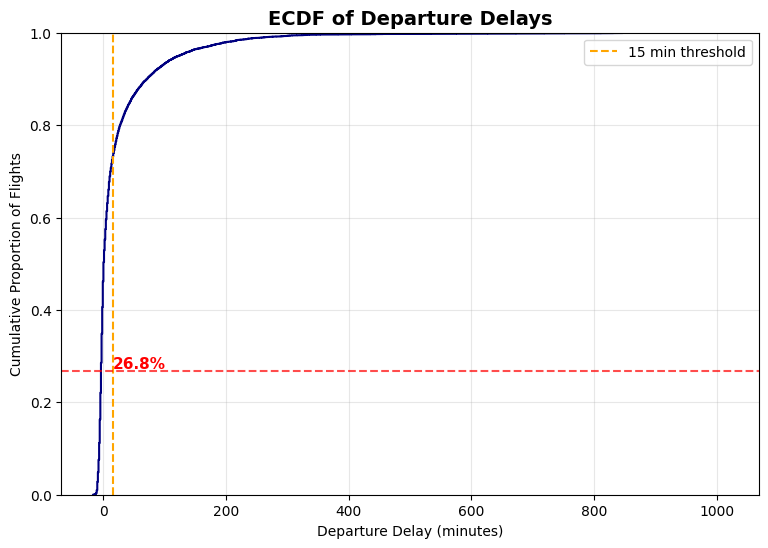

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(9,6))
sns.ecdfplot(df_master["dep_delay_min"], color="navy")

# 15-min cutoff
plt.axvline(15, color="orange", linestyle="--", label="15 min threshold")
plt.axhline(late_flights_pct/100, color="red", linestyle="--", alpha=0.7)
plt.text(15+1, late_flights_pct/100, f"{late_flights_pct:.1f}%",
         color="red", fontsize=11, va="bottom", weight="bold")

plt.title("ECDF of Departure Delays", fontsize=14, weight="bold")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Cumulative Proportion of Flights")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


EDA 2

In [ ]:
df_master["slack_mins"] = df_master["scheduled_ground_time_minutes"] - df_master["minimum_turn_minutes"]


In [ ]:
critical = (df_master["slack_mins"] <= 0).sum()
tight = ((df_master["slack_mins"] > 0) & (df_master["slack_mins"] <= 10)).sum()
total = len(df_master)

print(f"Flights at/below minimum turn: {critical} ({critical/total*100:.1f}%)")
print(f"Flights within 10 min slack: {tight} ({tight/total*100:.1f}%)")


Flights at/below minimum turn: 633 (7.9%)
Flights within 10 min slack: 530 (6.6%)


In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DejaVu Sans"


Flights at/below minimum (≤0): 633 (7.9%)
Flights with tight slack (1–10): 530 (6.6%)
Flights comfortable (>10): 6900 (85.6%)
Total flights: 8063


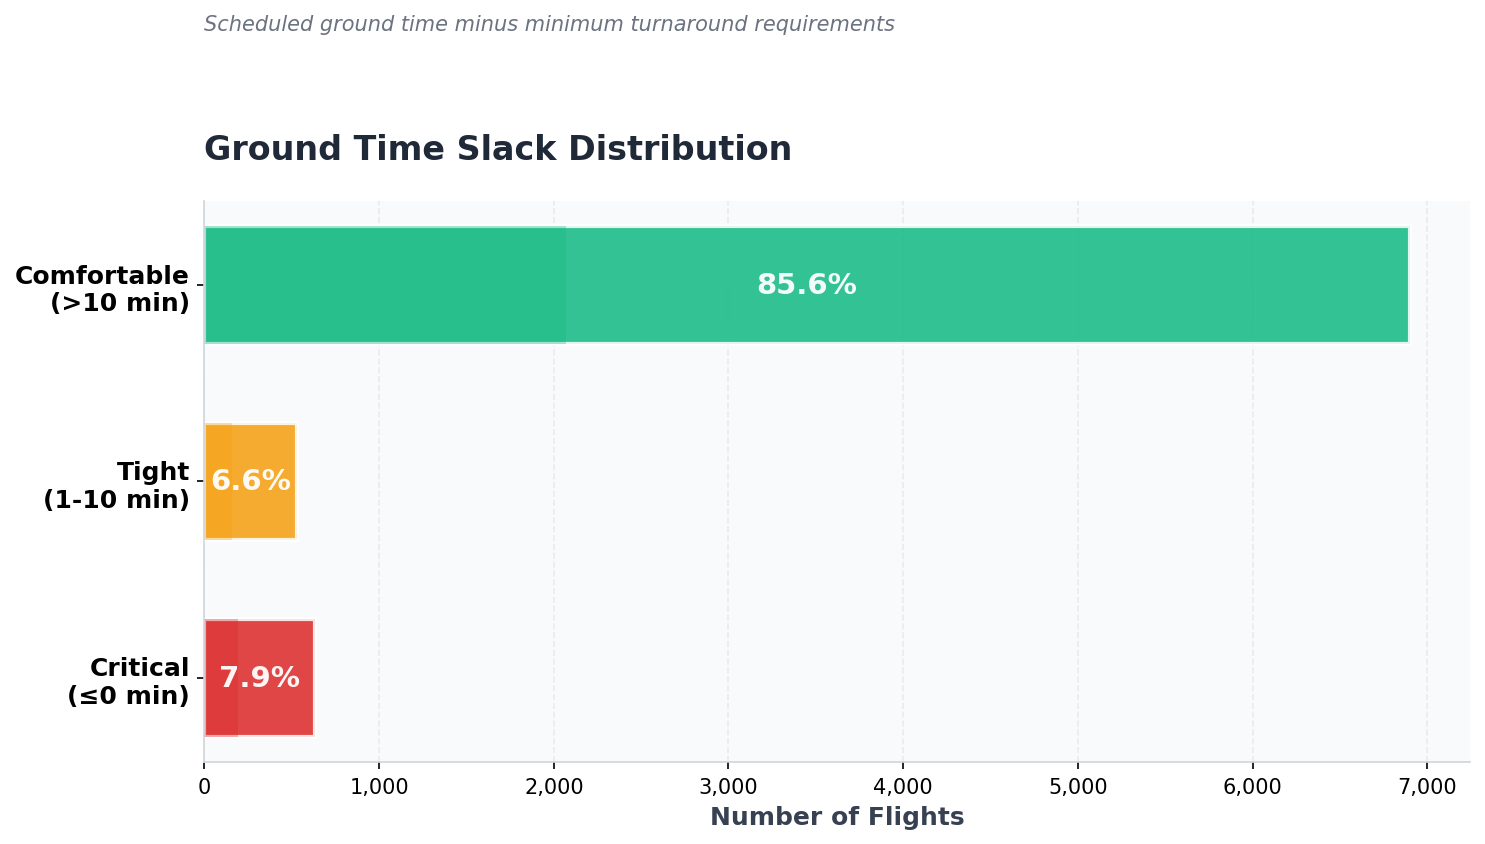

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate slack minutes
df_master["slack_mins"] = (
    df_master["scheduled_ground_time_minutes"] - df_master["minimum_turn_minutes"]
)

# Categorize flights
total = len(df_master)
critical = (df_master["slack_mins"] <= 0).sum()
tight = ((df_master["slack_mins"] > 0) & (df_master["slack_mins"] <= 10)).sum()
comfortable = total - critical - tight

def pct(x):
    return 100 * x / total

# Print results
print("Flights at/below minimum (≤0):", critical, f"({pct(critical):.1f}%)")
print("Flights with tight slack (1–10):", tight, f"({pct(tight):.1f}%)")
print("Flights comfortable (>10):", comfortable, f"({pct(comfortable):.1f}%)")
print("Total flights:", total)

# Create stunning horizontal bar chart with gradient effect
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

categories = ["Critical\n(≤0 min)", "Tight\n(1-10 min)", "Comfortable\n(>10 min)"]
counts = [critical, tight, comfortable]
percentages = [pct(critical), pct(tight), pct(comfortable)]

# Color palette: red → orange → green gradient
colors = ["#dc2626", "#f59e0b", "#10b981"]
y_positions = np.arange(len(categories))

# Create horizontal bars with enhanced styling
bars = ax.barh(y_positions, counts, height=0.6, color=colors,
               edgecolor="white", linewidth=2, alpha=0.85)

# Add gradient-like effect with lighter overlay bars
for i, (bar, color) in enumerate(zip(bars, colors)):
    width = bar.get_width()
    # Add a lighter overlay for depth
    ax.barh(i, width * 0.3, height=0.6, left=0,
            color=color, alpha=0.3, edgecolor="none")

# Add percentage labels in center of bars
for i, pct_val in enumerate(percentages):
    ax.text(counts[i] / 2, i, f"{pct_val:.1f}%",
            va="center", ha="center", fontsize=14, weight="bold",
            color="white", alpha=0.95)

# Styling
ax.set_yticks(y_positions)
ax.set_yticklabels(categories, fontsize=12, weight="600")
ax.set_xlabel("Number of Flights", fontsize=12, weight="600", color="#374151")
ax.set_title("Ground Time Slack Distribution",
             fontsize=16, weight="bold", pad=20, color="#1f2937",
             loc="left")

# Subtitle
ax.text(0, len(categories) + 0.3,
        "Scheduled ground time minus minimum turnaround requirements",
        fontsize=10, color="#6b7280", style="italic")

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#d1d5db")
ax.spines["bottom"].set_color("#d1d5db")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.2, linewidth=0.8)
ax.set_axisbelow(True)

# Background
ax.set_facecolor("#f9fafb")
fig.patch.set_facecolor("white")

# Format x-axis with thousands separator
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

EDA 3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Valid flights (avoid divide-by-zero)
valid = df_master[df_master["checked_bags"] > 0].copy()

# 2) Flight-level metrics
valid["transfer_ratio"] = valid["transfer_bags"] / valid["checked_bags"]
valid["transfer_share"] = valid["transfer_bags"] / (valid["transfer_bags"] + valid["checked_bags"])

# 3) Summary (unweighted vs weighted)
unweighted_mean_ratio = valid["transfer_ratio"].mean()
weighted_mean_ratio   = valid["transfer_bags"].sum() / valid["checked_bags"].sum()

unweighted_mean_share = valid["transfer_share"].mean()
weighted_mean_share   = valid["transfer_bags"].sum() / (valid["transfer_bags"].sum() + valid["checked_bags"].sum())

print(f"Unweighted mean ratio (transfer/checked): {unweighted_mean_ratio:.3f}")
print(f"Weighted mean ratio   (transfer/checked): {weighted_mean_ratio:.3f}  <-- use this in slides")
print(f"Unweighted mean share (transfer/total):   {unweighted_mean_share:.3f}")
print(f"Weighted mean share   (transfer/total):   {weighted_mean_share:.3f}  <-- also good for slides")



Unweighted mean ratio (transfer/checked): 3.558
Weighted mean ratio   (transfer/checked): 1.245  <-- use this in slides
Unweighted mean share (transfer/total):   0.593
Weighted mean share   (transfer/total):   0.555  <-- also good for slides


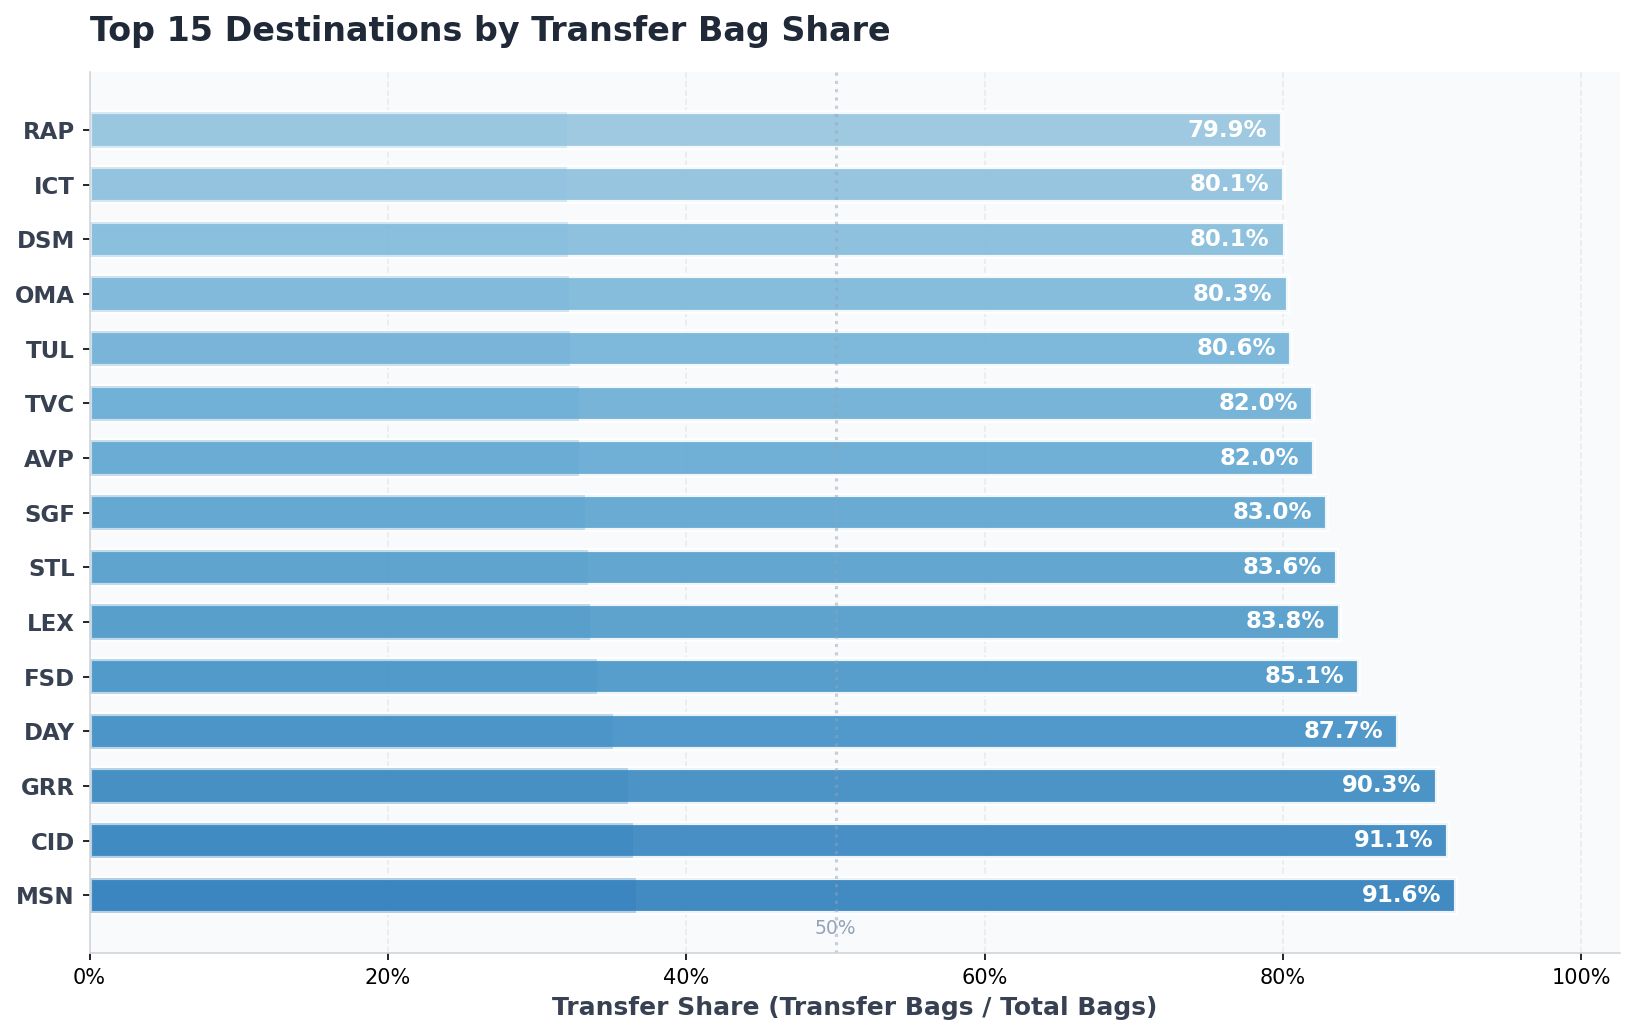

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate weighted ratios by destination
by_dest = (
    valid.groupby("scheduled_arrival_station_code")[["transfer_bags","checked_bags"]]
         .sum()
         .query("checked_bags > 0")
         .assign(weighted_ratio=lambda d: d["transfer_bags"]/d["checked_bags"],
                 transfer_share=lambda d: d["transfer_bags"]/(d["transfer_bags"]+d["checked_bags"]))
)

top15 = by_dest.sort_values("transfer_share", ascending=False).head(15)

# Create figure
fig, ax = plt.subplots(figsize=(11, 7), dpi=150)

y_positions = np.arange(len(top15))
x_values = top15["transfer_share"].values
destinations = top15.index

# Color gradient from dark to light blue
colors = plt.cm.Blues(np.linspace(0.7, 0.4, len(top15)))

# Create horizontal bars with gradient
bars = ax.barh(y_positions, x_values, height=0.65,
               color=colors, edgecolor="white", linewidth=2, alpha=0.9)

# Add shimmer effect with lighter overlay
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.barh(i, width * 0.4, height=0.65, left=0,
            color=colors[i], alpha=0.3, edgecolor="none")

# Add percentage labels at the end of bars
for i, (dest, val) in enumerate(zip(destinations, x_values)):
    # Percentage inside or outside bar depending on width
    if val > 0.15:
        ax.text(val - 0.01, i, f"{val:.1%}",
                va="center", ha="right", fontsize=11, weight="bold",
                color="white")
    else:
        ax.text(val + 0.01, i, f"{val:.1%}",
                va="center", ha="left", fontsize=11, weight="bold",
                color="#1f2937")

# Styling
ax.set_yticks(y_positions)
ax.set_yticklabels(destinations, fontsize=11, weight="600", color="#374151")
ax.set_xlabel("Transfer Share (Transfer Bags / Total Bags)",
              fontsize=12, weight="600", color="#374151")

# Title with subtitle
ax.set_title("Top 15 Destinations by Transfer Bag Share",
             fontsize=16, weight="bold", pad=15, color="#1f2937", loc="left")


# Format x-axis as percentage
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.set_xlim(0, max(x_values) * 1.12)

# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#d1d5db")
ax.spines["bottom"].set_color("#d1d5db")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.2, linewidth=0.8)
ax.set_axisbelow(True)

# Background
ax.set_facecolor("#f9fafb")
fig.patch.set_facecolor("white")

# Add subtle vertical line at 50%
if max(x_values) > 0.5:
    ax.axvline(0.5, color="#94a3b8", linestyle=":", linewidth=1.5, alpha=0.5)
    ax.text(0.5, -0.7, "50%", ha="center", fontsize=9, color="#94a3b8")

plt.tight_layout()
plt.show()

EDA 4

In [ ]:
import pandas as pd

# Create bins
df_master["load_bin"] = pd.cut(
    df_master["load_factor"],
    bins=[0, 0.6, 0.8, 0.9, 1.0, 1.1],
    labels=["0–0.6","0.6–0.8","0.8–0.9","0.9–1.0",">1.0"]
)


In [ ]:
heatmap_data = df_master.groupby(["load_bin","dep_dow"])["dep_delay_min"].mean().unstack()

# Order days properly (Mon–Sun, assuming dep_dow = 0=Mon)
dow_order = [0,1,2,3,4,5,6]
heatmap_data = heatmap_data[dow_order]
heatmap_data.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]


/tmp/ipython-input-96841212.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_master.groupby(["load_bin","dep_dow"])["dep_delay_min"].mean().unstack()


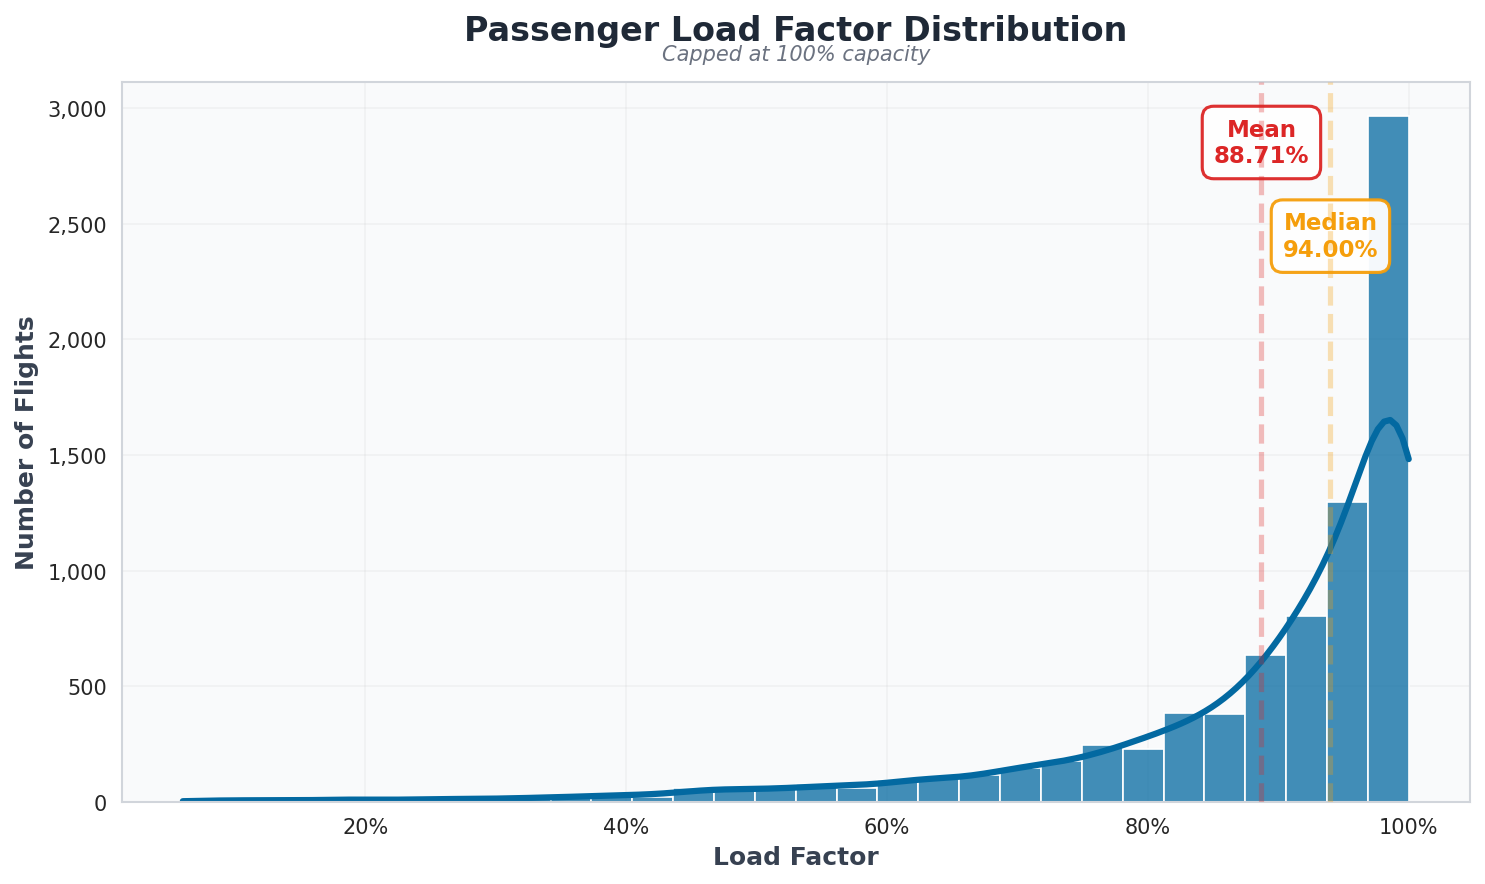

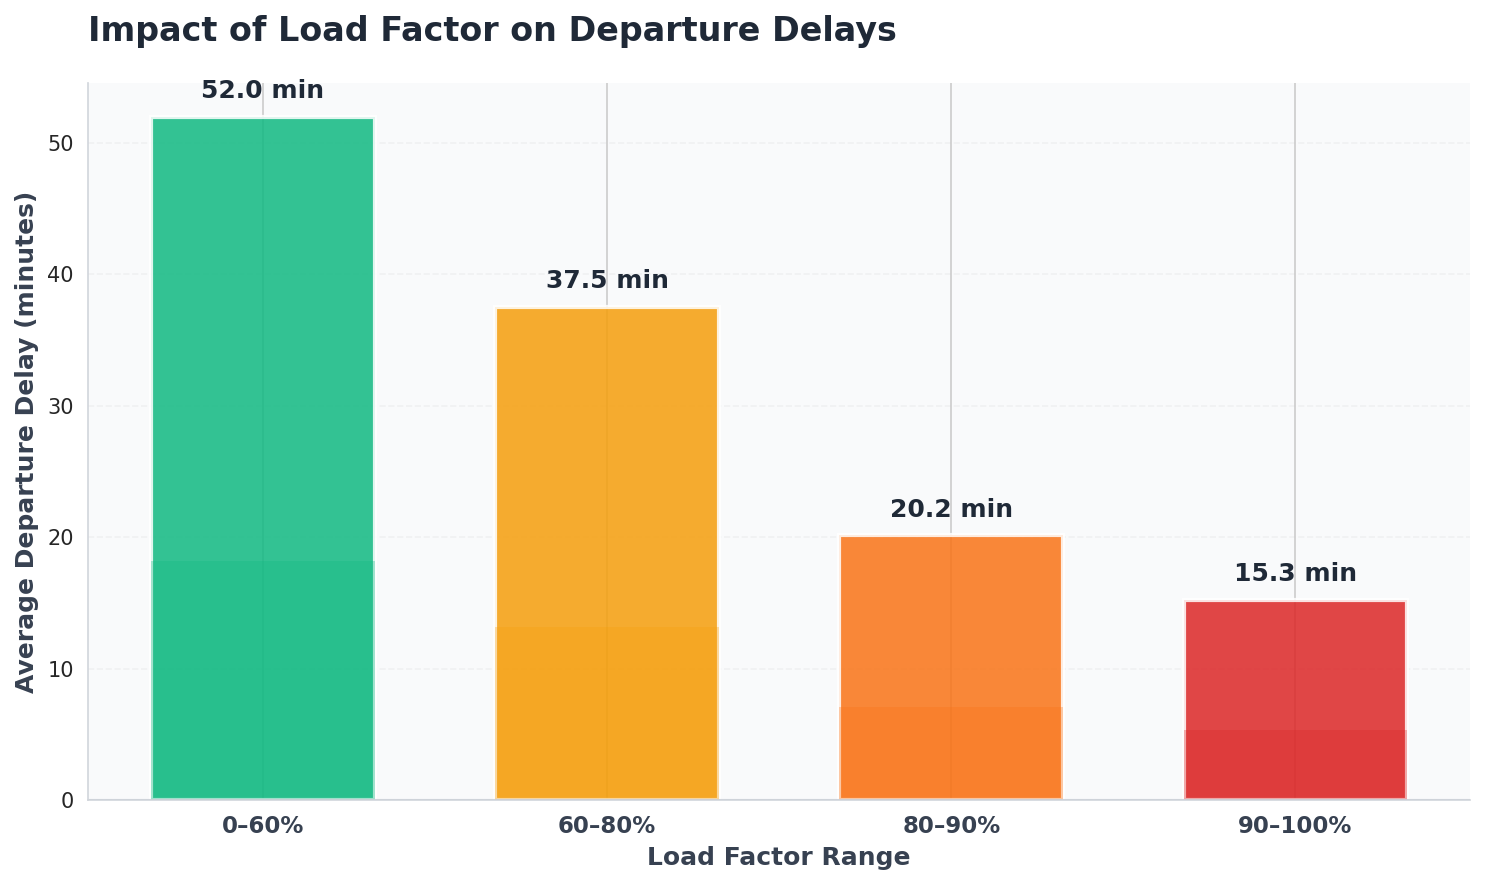

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set style
sns.set_style("whitegrid")

# ==============================================================================
# Step 1: Compute capped load factor
# ==============================================================================
df_master["load_factor"] = (
    df_master["pax_total"] / df_master["total_seats"]
).clip(upper=1)

# ==============================================================================
# Step 2: Distribution of Load Factors
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Histogram with KDE
sns.histplot(df_master["load_factor"], bins=30, kde=True,
             color="#0369a1", alpha=0.75, edgecolor="white",
             linewidth=0.8, line_kws={"linewidth": 3, "color": "#0284c7"},
             ax=ax)

# Calculate statistics
mean_lf = df_master["load_factor"].mean()
median_lf = df_master["load_factor"].median()

# Mean line
ax.axvline(mean_lf, color="#dc2626", linestyle="--", linewidth=2.5,
           alpha=0.3, zorder=10)
ax.text(mean_lf, ax.get_ylim()[1] * 0.95, f"Mean\n{mean_lf:.2%}",
        color="#dc2626", fontsize=11, weight="bold", ha="center",
        va="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                           edgecolor="#dc2626", alpha=0.95, linewidth=1.5))

# Median line
ax.axvline(median_lf, color="#f59e0b", linestyle="--", linewidth=2.5,
           alpha=0.3, zorder=10)
ax.text(median_lf, ax.get_ylim()[1] * 0.82, f"Median\n{median_lf:.2%}",
        color="#f59e0b", fontsize=11, weight="bold", ha="center",
        va="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                           edgecolor="#f59e0b", alpha=0.95, linewidth=1.5))

# Styling
ax.set_title("Passenger Load Factor Distribution",
             fontsize=16, weight="bold", pad=20, color="#1f2937")
ax.text(0.5, 1.03, "Capped at 100% capacity",
        transform=ax.transAxes, fontsize=10, color="#6b7280",
        style="italic", ha="center")

ax.set_xlabel("Load Factor", fontsize=12, weight="600", color="#374151")
ax.set_ylabel("Number of Flights", fontsize=12, weight="600", color="#374151")

# Format x-axis as percentage
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

ax.grid(True, alpha=0.2, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_facecolor("#f9fafb")
fig.patch.set_facecolor("white")

for spine in ax.spines.values():
    spine.set_color("#d1d5db")
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

# ==============================================================================
# Step 3: Delay Correlation with Load Factor
# ==============================================================================
df_master["load_bin"] = pd.cut(
    df_master["load_factor"],
    bins=[0, 0.6, 0.8, 0.9, 1.0],
    labels=["0–60%", "60–80%", "80–90%", "90–100%"]
)

delay_by_load = df_master.groupby("load_bin", observed=True)["dep_delay_min"].mean()

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Create gradient colors from green to red
colors = ["#10b981", "#f59e0b", "#f97316", "#dc2626"]
x_pos = np.arange(len(delay_by_load))

# Create bars with gradient
bars = ax.bar(x_pos, delay_by_load.values, width=0.65,
              color=colors, edgecolor="white", linewidth=2, alpha=0.85)

# Add shimmer effect
for i, (bar, color) in enumerate(zip(bars, colors)):
    height = bar.get_height()
    ax.bar(i, height * 0.35, width=0.65, bottom=0,
           color=color, alpha=0.3, edgecolor="none")

# Add value labels on top of bars
for i, val in enumerate(delay_by_load.values):
    ax.text(i, val + max(delay_by_load.values) * 0.02, f"{val:.1f} min",
            ha="center", va="bottom", fontsize=12, weight="bold",
            color="#1f2937")

# Styling
ax.set_xticks(x_pos)
ax.set_xticklabels(delay_by_load.index, fontsize=11, weight="600",
                   color="#374151")
ax.set_xlabel("Load Factor Range", fontsize=12, weight="600",
              color="#374151")
ax.set_ylabel("Average Departure Delay (minutes)", fontsize=12,
              weight="600", color="#374151")

ax.set_title("Impact of Load Factor on Departure Delays",
             fontsize=16, weight="bold", pad=20, color="#1f2937", loc="left")


# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#d1d5db")
ax.spines["bottom"].set_color("#d1d5db")

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.2, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_facecolor("#f9fafb")
fig.patch.set_facecolor("white")

# Add subtle horizontal line at zero
ax.axhline(0, color="#94a3b8", linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()


EDA 5


In [ ]:
df_master["ssr_per_100pax"] = df_master["ssr_count"] / (df_master["pax_total"]+1) * 100



In [ ]:
import numpy as np
import pandas as pd

# --- 1. Load bins (fixed thresholds) ---
df_master["load_bin"] = pd.cut(
    df_master["load_factor_capped"],
    bins=[0, 0.7, 0.85, 1.0],
    labels=["Low Load", "Medium Load", "High Load"]
)

# --- 2. SSR bins (quantile-based, safer) ---
df_master["ssr_bin"] = pd.qcut(
    df_master["ssr_per_100pax"],
    q=3,
    labels=["Low SSR", "Medium SSR", "High SSR"],
    duplicates="drop"   # <--- important fix
)



/tmp/ipython-input-1885995382.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_master.pivot_table(index="load_bin", columns="ssr_bin", values="dep_delay_min", aggfunc="mean")


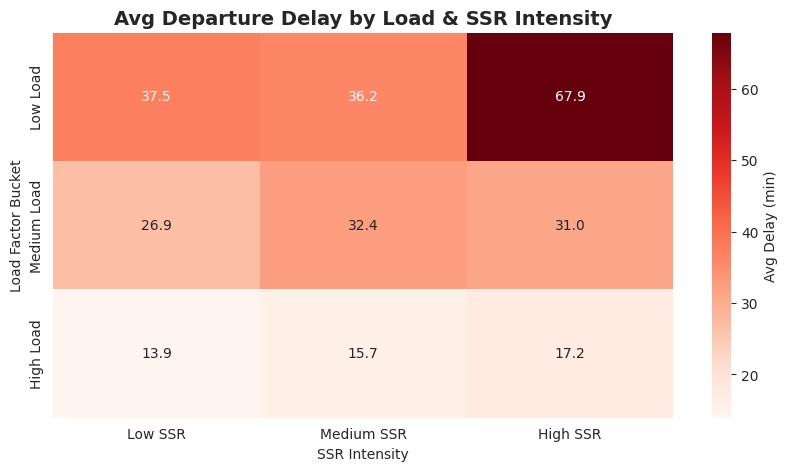

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df_master.pivot_table(index="load_bin", columns="ssr_bin", values="dep_delay_min", aggfunc="mean")

plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Avg Delay (min)'})
plt.title("Avg Departure Delay by Load & SSR Intensity", fontsize=14, weight="bold")
plt.xlabel("SSR Intensity"); plt.ylabel("Load Factor Bucket")
plt.show()


EDA 6

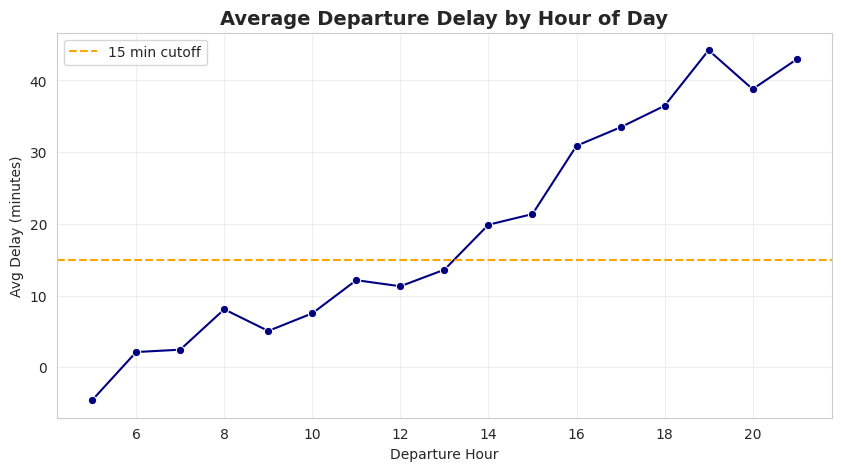

In [ ]:
avg_delay_by_hour = df_master.groupby("dep_hour")["dep_delay_min"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x="dep_hour", y="dep_delay_min", data=avg_delay_by_hour, marker="o", color="navy")
plt.axhline(15, color="orange", linestyle="--", label="15 min cutoff")

plt.title("Average Departure Delay by Hour of Day", fontsize=14, weight="bold")
plt.xlabel("Departure Hour"); plt.ylabel("Avg Delay (minutes)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


EDA 7

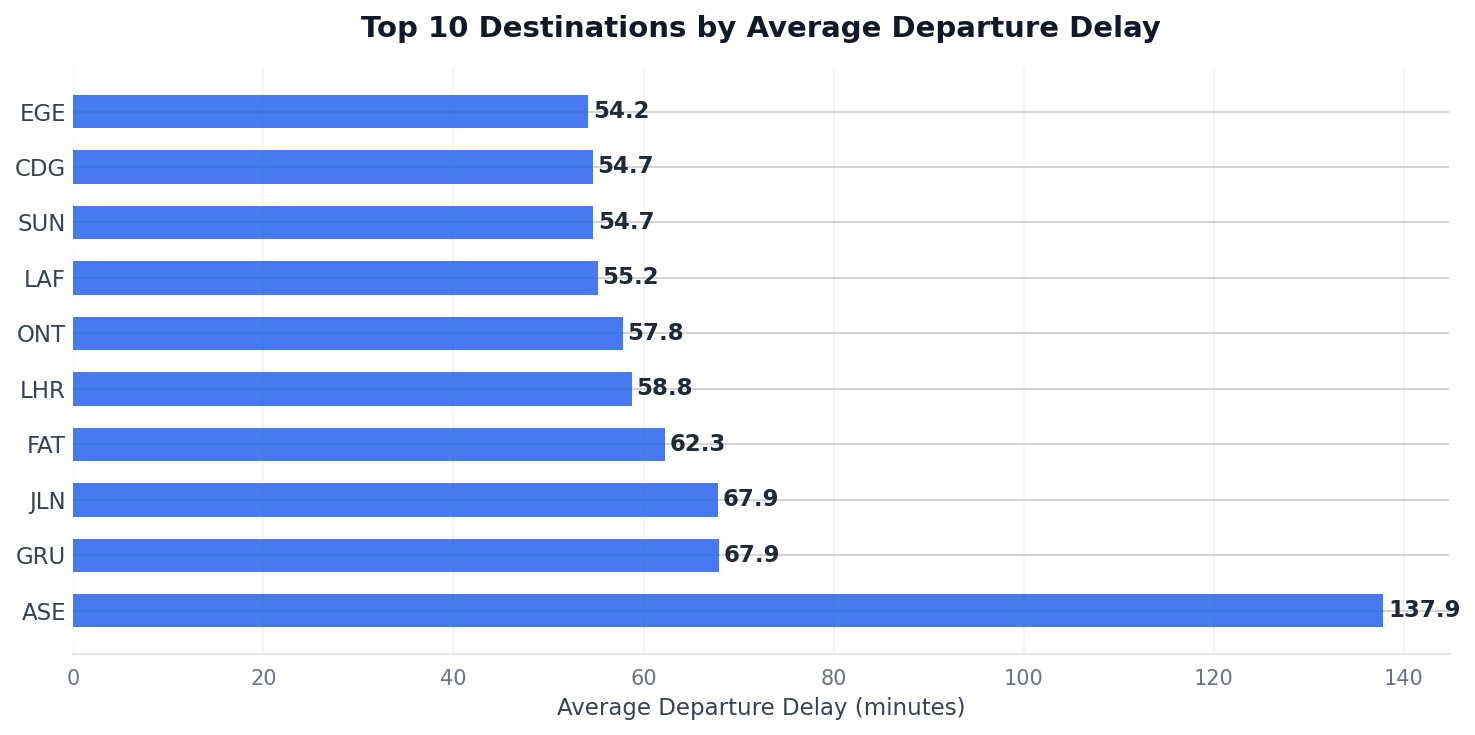

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate average delay by destination
avg_delay_by_dest = (
    df_master.groupby("scheduled_arrival_station_code")["dep_delay_min"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# Simple, elegant color scheme
y_positions = np.arange(len(avg_delay_by_dest))
x_values = avg_delay_by_dest.values
destinations = avg_delay_by_dest.index

# Create clean horizontal bars with single color
bars = ax.barh(y_positions, x_values, height=0.6,
               color="#2563eb", edgecolor="none", alpha=0.85)

# Add value labels at the end of bars
for i, val in enumerate(x_values):
    ax.text(val + 0.5, i, f"{val:.1f}",
            va="center", ha="left", fontsize=11,
            color="#1f2937", weight="600")


ax.set_yticks(y_positions)
ax.set_yticklabels(destinations, fontsize=11, color="#374151")
ax.set_xlabel("Average Departure Delay (minutes)",
              fontsize=11, color="#374151")

ax.set_title("Top 10 Destinations by Average Departure Delay",
             fontsize=14, weight="600", pad=15, color="#111827")

# Minimal spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#e5e7eb")
ax.spines["bottom"].set_linewidth(1)

# Subtle grid
ax.grid(axis="x", linestyle="-", alpha=0.1, linewidth=1, color="#9ca3af")
ax.set_axisbelow(True)

# Clean background
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Remove y-axis tick marks
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors="#6b7280")

plt.tight_layout()
plt.show()

Logistic Regression

In [ ]:
import numpy as np
import pandas as pd

# --- Ensure delay column exists ---
if "dep_delay_min" not in df_master.columns:
    df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
    df_master["actual_departure_datetime_local"] = pd.to_datetime(df_master["actual_departure_datetime_local"])
    df_master["dep_delay_min"] = (
        (df_master["actual_departure_datetime_local"] - df_master["scheduled_departure_datetime_local"])
        .dt.total_seconds() / 60
    )

# --- Target: difficult flight if departure delay > 15 min ---
df_master["is_difficult"] = (df_master["dep_delay_min"] > 15).astype(int)

# --- Core engineered features ---
# Load factor (cap at 1.0)
df_master["load_factor"] = (df_master["pax_total"] / df_master["total_seats"]).clip(upper=1.0)

# Slack minutes (buffer vs minimum turn)
if "slack_mins" not in df_master.columns:
    df_master["slack_mins"] = df_master["scheduled_ground_time_minutes"] - df_master["minimum_turn_minutes"]

# Transfer share & bag volume
checked = df_master["checked_bags"].fillna(0)
transfer = df_master["transfer_bags"].fillna(0)
total_bags = checked + transfer
df_master["transfer_share"] = np.where(total_bags > 0, transfer / total_bags, 0.0)
df_master["bag_volume"] = total_bags

# SSR per 100 pax (normalizes SSR by load)
pax = df_master["pax_total"].fillna(0)
df_master["ssr_per_100pax"] = np.where(pax > 0, df_master["ssr_count"] / pax * 100, 0.0)

# Time features
df_master["dep_hour"] = df_master["dep_hour"].astype(int)  # already computed earlier from timestamps
# cyclical encoding for hour (helps tree-free models; harmless otherwise)
df_master["dep_hour_sin"] = np.sin(2 * np.pi * df_master["dep_hour"] / 24)
df_master["dep_hour_cos"] = np.cos(2 * np.pi * df_master["dep_hour"] / 24)

# Categorical features (fill unknowns now; encoding in next step)
for col in ["fleet_type", "carrier", "arrival_country"]:
    df_master[col] = df_master[col].fillna("UNK").astype(str)

# --- Select feature set for modeling ---
feature_cols = [
    # numeric drivers
    "slack_mins", "load_factor", "ssr_count", "ssr_per_100pax",
    "transfer_share", "bag_volume",
    "dep_hour_sin", "dep_hour_cos",
    # simple numeric time flags
    "dep_dow",
    # raw counts (optional but useful for trees)
    "checked_bags", "transfer_bags",
    # categoricals (to be encoded next)
    "fleet_type", "carrier", "arrival_country"
]

model_df = df_master[["company_id","flight_number","scheduled_departure_date_local","dep_delay_min","is_difficult"] + feature_cols].copy()

# --- Quick NA hygiene for numerics (categoricals handled next step) ---
num_cols = [c for c in feature_cols if c not in ["fleet_type","carrier","arrival_country"]]
model_df[num_cols] = model_df[num_cols].fillna(0)

# --- Sanity prints ---
print("Modeling frame shape:", model_df.shape)
print("Target distribution (is_difficult):")
print(model_df["is_difficult"].value_counts(normalize=True).rename(lambda k: f"{k}").map(lambda v: f"{v*100:.1f}%"))
print("\nSample columns:\n", model_df.columns.tolist())
model_df.head(3)


Modeling frame shape: (8063, 19)
Target distribution (is_difficult):
is_difficult
0    73.2%
1    26.8%
Name: proportion, dtype: object

Sample columns:
 ['company_id', 'flight_number', 'scheduled_departure_date_local', 'dep_delay_min', 'is_difficult', 'slack_mins', 'load_factor', 'ssr_count', 'ssr_per_100pax', 'transfer_share', 'bag_volume', 'dep_hour_sin', 'dep_hour_cos', 'dep_dow', 'checked_bags', 'transfer_bags', 'fleet_type', 'carrier', 'arrival_country']


,company_id,flight_number,scheduled_departure_date_local,dep_delay_min,is_difficult,slack_mins,load_factor,ssr_count,ssr_per_100pax,transfer_share,bag_volume,dep_hour_sin,dep_hour_cos,dep_dow,checked_bags,transfer_bags,fleet_type,carrier,arrival_country
0,UA,622,2025-08-01,0.0,0,12,0.994505,4,1.104972,0.255725,262,-0.258819,-9.659258e-01,5,195,67,B777-2HD,Mainline,US
1,UA,2154,2025-08-01,0.0,0,19,0.977654,4,2.285714,0.873950,119,-1.000000,-1.836970e-16,5,15,104,B737-900,Mainline,US
2,OO,5429,2025-08-02,-4.0,0,29,1.000000,1,1.315789,0.655172,58,-0.500000,-8.660254e-01,6,20,38,ERJ-175,Express,US


ROC AUC: 0.697

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.63      0.72      1771
           1       0.40      0.67      0.50       648

    accuracy                           0.64      2419
   macro avg       0.62      0.65      0.61      2419
weighted avg       0.72      0.64      0.66      2419



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


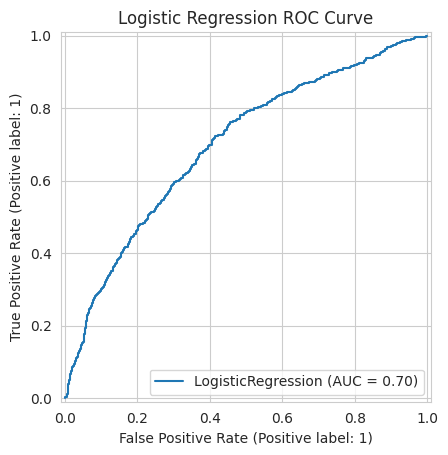

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

# --- 1. Separate features & target ---
X = model_df.drop(columns=["company_id","flight_number","scheduled_departure_date_local","dep_delay_min","is_difficult"])
y = model_df["is_difficult"]

# Identify categorical columns
cat_cols = ["fleet_type","carrier","arrival_country"]
num_cols = [c for c in X.columns if c not in cat_cols]

# --- 2. Encode categoricals (one-hot) ---
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])
cat_feature_names = ohe.get_feature_names_out(cat_cols)

X_encoded = pd.DataFrame(
    np.hstack([X[num_cols].values, X_cat]),
    columns=num_cols + list(cat_feature_names)
)

# --- 3. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

# --- 4. Train Logistic Regression ---
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")  # balanced handles skew
logreg.fit(X_train, y_train)

# --- 5. Evaluate ---
y_pred_prob = logreg.predict_proba(X_test)[:,1]
y_pred = (y_pred_prob > 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", round(auc,3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 6. ROC curve plot ---
RocCurveDisplay.from_estimator(logreg, X_test, y_test)
plt.title("Logistic Regression ROC Curve")
plt.show()


ROC AUC: 0.696
Best threshold (F1): 0.421

Classification Report @best F1 threshold:
               precision    recall  f1-score   support

           0      0.862     0.535     0.660      1771
           1      0.376     0.765     0.504       648

    accuracy                          0.597      2419
   macro avg      0.619     0.650     0.582      2419
weighted avg      0.732     0.597     0.618      2419



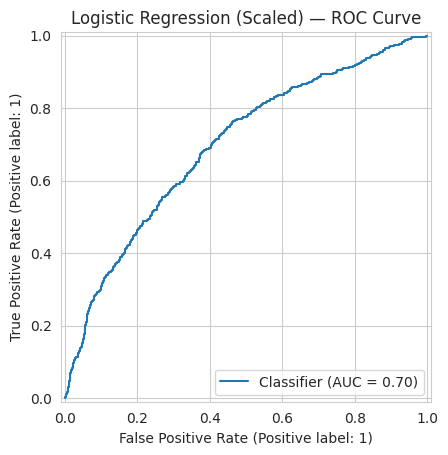

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, precision_recall_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# --- features / target ---
X = model_df.drop(columns=["company_id","flight_number","scheduled_departure_date_local","dep_delay_min","is_difficult"])
y = model_df["is_difficult"]

cat_cols = ["fleet_type","carrier","arrival_country"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- preprocessing: scale nums, one-hot cats ---
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

# --- logistic model ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=5000,          # high to ensure convergence
    class_weight="balanced",
    n_jobs=-1
)

pipe = Pipeline(steps=[("pre", pre), ("clf", logreg)])
pipe.fit(X_train, y_train)

# --- eval (probabilities) ---
proba = pipe.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"ROC AUC: {auc:.3f}")

# --- choose an operating threshold (maximize F1 or Youden's J) ---
prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2*(prec*rec)/(prec+rec + 1e-12)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx-1] if best_idx > 0 else 0.5   # precision_recall_curve thr len = n-1

print(f"Best threshold (F1): {best_thr:.3f}")
y_pred = (proba >= best_thr).astype(int)

print("\nClassification Report @best F1 threshold:\n",
      classification_report(y_test, y_pred, digits=3))

# ROC curve (slide-ready)
RocCurveDisplay.from_predictions(y_test, proba)
plt.title("Logistic Regression (Scaled) — ROC Curve")
plt.show()


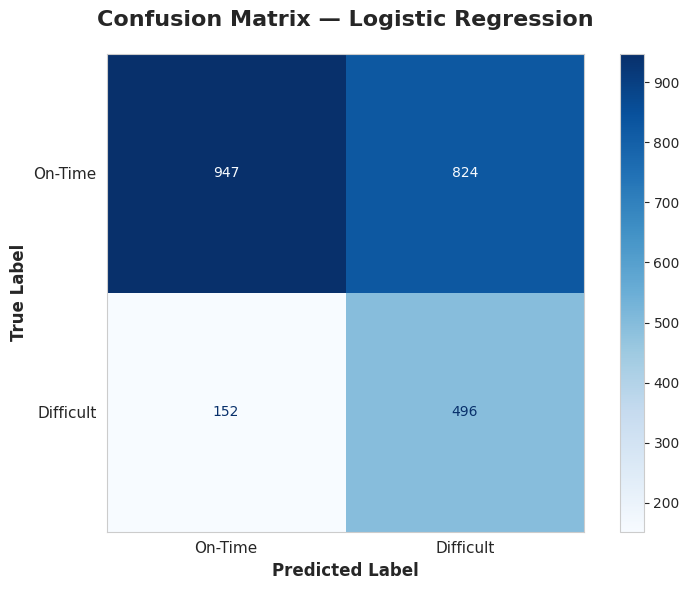

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create figure with better sizing
fig, ax = plt.subplots(figsize=(8, 6))

# Create confusion matrix display with custom styling
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On-Time", "Difficult"]
)

# Plot with enhanced aesthetics
disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    values_format='d'
)

# Customize the plot
ax.set_title(
    "Confusion Matrix — Logistic Regression",
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight='semibold')
ax.set_ylabel("True Label", fontsize=12, fontweight='semibold')

# Improve tick labels
ax.tick_params(labelsize=11)

# Add grid for better readability
ax.grid(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Separate categorical and numeric columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

# Preprocessing: scale numeric, encode categorical
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Pipeline
pipe = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['slack_mins', 'load_factor', 'ssr_count', 'ssr_per_100pax',
       'transfer_share', 'bag_volume', 'dep_hour_sin', 'dep_hour_cos',
       'dep_dow', 'checked_bags', 'transfer_bags'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['fleet_type', 'carrier', 'arrival_country'], dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000))])

In [ ]:
# Group categorical features into families
family_map = []
for f in coefs.index:
    if f.startswith("arrival_country"):
        family_map.append("Arrival Country")
    elif f.startswith("fleet_type"):
        family_map.append("Fleet Type")
    elif f.startswith("carrier"):
        family_map.append("Carrier")
    else:
        family_map.append(f)

# Take mean absolute coefficient per family
grouped = coefs.groupby(family_map).apply(lambda x: x.abs().mean())
grouped = grouped.sort_values(ascending=False)


NameError: name 'coefs' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5), dpi=150)
sns.barplot(x=grouped.values, y=grouped.index, palette="viridis")
plt.title("Logistic Regression — Key Feature Importance", fontsize=14, weight="bold")
plt.xlabel("Average |Coefficient|")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()


NameError: name 'grouped' is not defined

<Figure size 1050x750 with 0 Axes>

Random Forest

Random Forest ROC AUC: 0.762

Classification Report (0.5 threshold):
               precision    recall  f1-score   support

           0      0.806     0.941     0.868      1771
           1      0.703     0.380     0.493       648

    accuracy                          0.791      2419
   macro avg      0.754     0.660     0.681      2419
weighted avg      0.778     0.791     0.768      2419



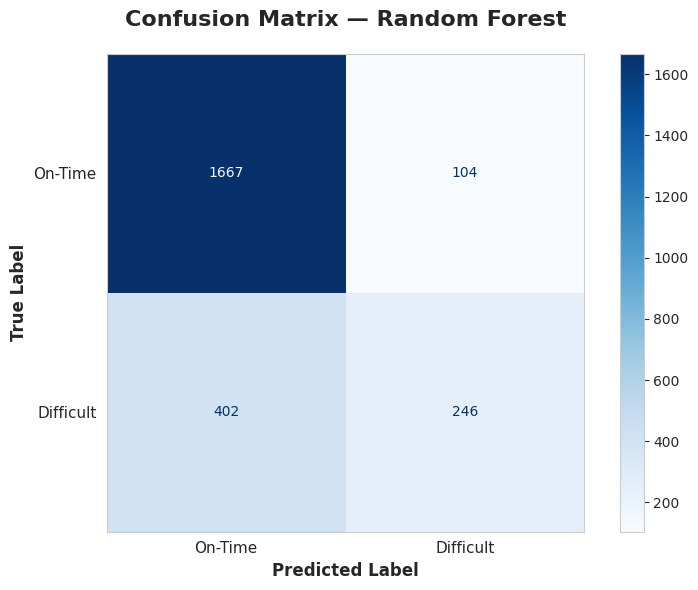

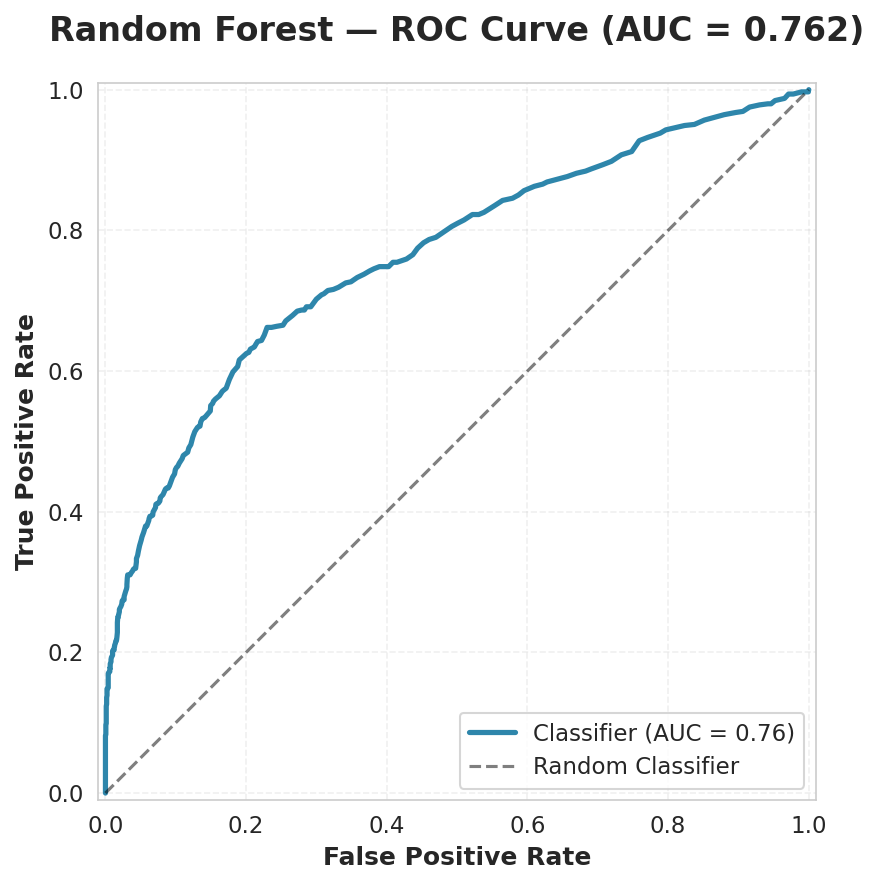

ValueError: operands could not be broadcast together with shapes (11,) (49,) 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline  # ← Add this
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# --- 1. Define RF model ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

pipe_rf = Pipeline(steps=[("pre", pre), ("clf", rf)])
pipe_rf.fit(X_train, y_train)

# --- 2. Predictions ---
rf_proba = pipe_rf.predict_proba(X_test)[:,1]
rf_pred = (rf_proba >= 0.5).astype(int)

# --- 3. Metrics ---
rf_auc = roc_auc_score(y_test, rf_proba)
print("Random Forest ROC AUC:", round(rf_auc, 3))
print("\nClassification Report (0.5 threshold):\n", classification_report(y_test, rf_pred, digits=3))

# ========== CONFUSION MATRIX ==========
cm = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On-Time", "Difficult"]
)
disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True,
    values_format='d'
)

ax.set_title(
    "Confusion Matrix — Random Forest",
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("Predicted Label", fontsize=12, fontweight='semibold')
ax.set_ylabel("True Label", fontsize=12, fontweight='semibold')
ax.tick_params(labelsize=11)
ax.grid(False)

plt.tight_layout()
plt.show()

# ========== ROC CURVE ==========
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

roc_display = RocCurveDisplay.from_predictions(
    y_test,
    rf_proba,
    ax=ax,
    color='#2E86AB',
    lw=2.5
)

# Enhance the plot
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
ax.set_title(
    f"Random Forest — ROC Curve (AUC = {rf_auc:.3f})",
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight='semibold')
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight='semibold')
ax.tick_params(labelsize=11)
ax.legend(loc='lower right', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ========== FEATURE IMPORTANCES ==========
importances = pipe_rf.named_steps["clf"].feature_importances_

# Rebuild feature names
ohe = pipe_rf.named_steps["pre"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)
feat_names = num_cols + list(cat_feature_names)

imp_df = pd.DataFrame({
    "Feature": feat_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

# Create enhanced barplot
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)

# Create gradient color palette
colors = plt.cm.viridis(imp_df['Importance'] / imp_df['Importance'].max())

bars = ax.barh(
    range(len(imp_df)),
    imp_df['Importance'].values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Customize axes
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['Feature'].values, fontsize=11)
ax.invert_yaxis()

# Labels and title
ax.set_xlabel("Importance Score", fontsize=12, fontweight='semibold')
ax.set_title(
    "Top 15 Feature Importances — Random Forest",
    fontsize=15,
    fontweight='bold',
    pad=20
)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, imp_df['Importance'].values)):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9,
        fontweight='semibold'
    )

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


Scoring

In [ ]:
# --- Difficulty score from Random Forest ---
df_master["difficulty_score"] = pipe_rf.predict_proba(X)[:, 1]

# --- Daily Ranking ---
df_master["daily_rank"] = (
    df_master.groupby("scheduled_departure_date_local")["difficulty_score"]
    .rank(method="first", ascending=False)
)

# --- Daily Percentile (0 = hardest, 1 = easiest) ---
df_master["rank_pct"] = (
    (df_master["daily_rank"] - 1) /
    (df_master.groupby("scheduled_departure_date_local")["difficulty_score"].transform("size") - 1)
)

# --- Classification (per day) ---
df_master["difficulty_class"] = pd.cut(
    df_master["rank_pct"],
    bins=[0, 0.2, 0.5, 1.0],
    labels=["Difficult", "Medium", "Easy"],
    include_lowest=True
)

# --- Final Submission DataFrame ---
submission_cols = [
    "company_id","flight_number","scheduled_departure_date_local",
    "difficulty_score","daily_rank","difficulty_class",
    "slack_mins","load_factor","ssr_count","transfer_share","bag_volume","dep_hour","dep_dow"
]
submission = df_master[submission_cols].sort_values(
    ["scheduled_departure_date_local","daily_rank"]
)

# Save as required test_<yourname>.csv
submission.to_csv("test_yourname.csv", index=False)

print("✅ Submission file created with shape:", submission.shape)
submission.tail(20)


NameError: name 'pipe_rf' is not defined

/tmp/ipython-input-4094564269.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=submission, x="difficulty_class",


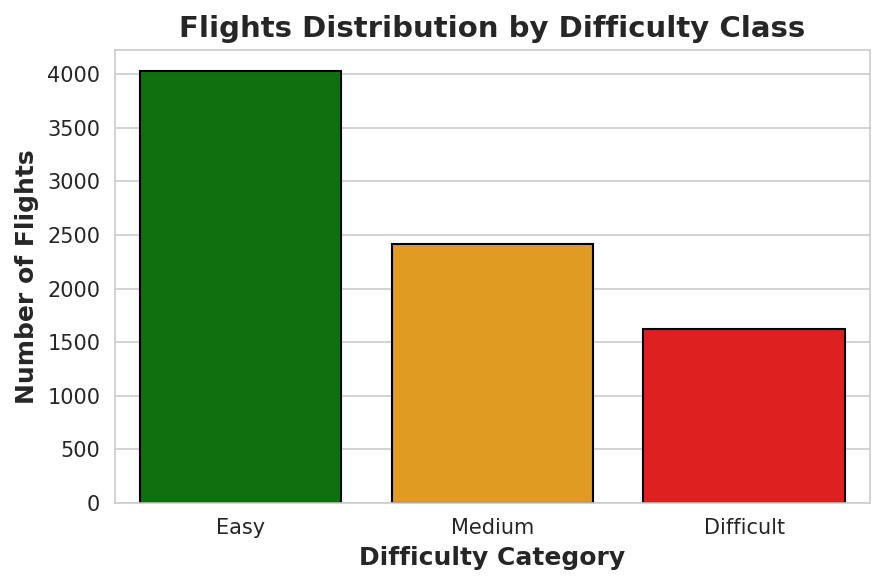

In [ ]:
plt.figure(figsize=(6,4), dpi=150)
sns.countplot(data=submission, x="difficulty_class",
              order=["Easy","Medium","Difficult"],
              palette={"Easy":"green","Medium":"orange","Difficult":"red"},
              edgecolor="black")

plt.title("Flights Distribution by Difficulty Class", fontsize=14, weight="bold")
plt.xlabel("Difficulty Category", fontsize=12, weight="bold")
plt.ylabel("Number of Flights", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


Part 3 Insights

In [ ]:
# Average difficulty score by destination
dest_difficulty = (
    submission.groupby("scheduled_arrival_station_code")["difficulty_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5), dpi=150)
sns.barplot(x=dest_difficulty.values, y=dest_difficulty.index, palette="Reds_r")
plt.title("Top 10 Difficult Destinations (Avg. Score)", fontsize=14, weight="bold")
plt.xlabel("Average Difficulty Score")
plt.ylabel("Destination")
plt.tight_layout()
plt.show()


KeyError: 'scheduled_arrival_station_code'

/tmp/ipython-input-3851460040.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_difficulty.values, y=dest_difficulty.index, palette="Reds_r")


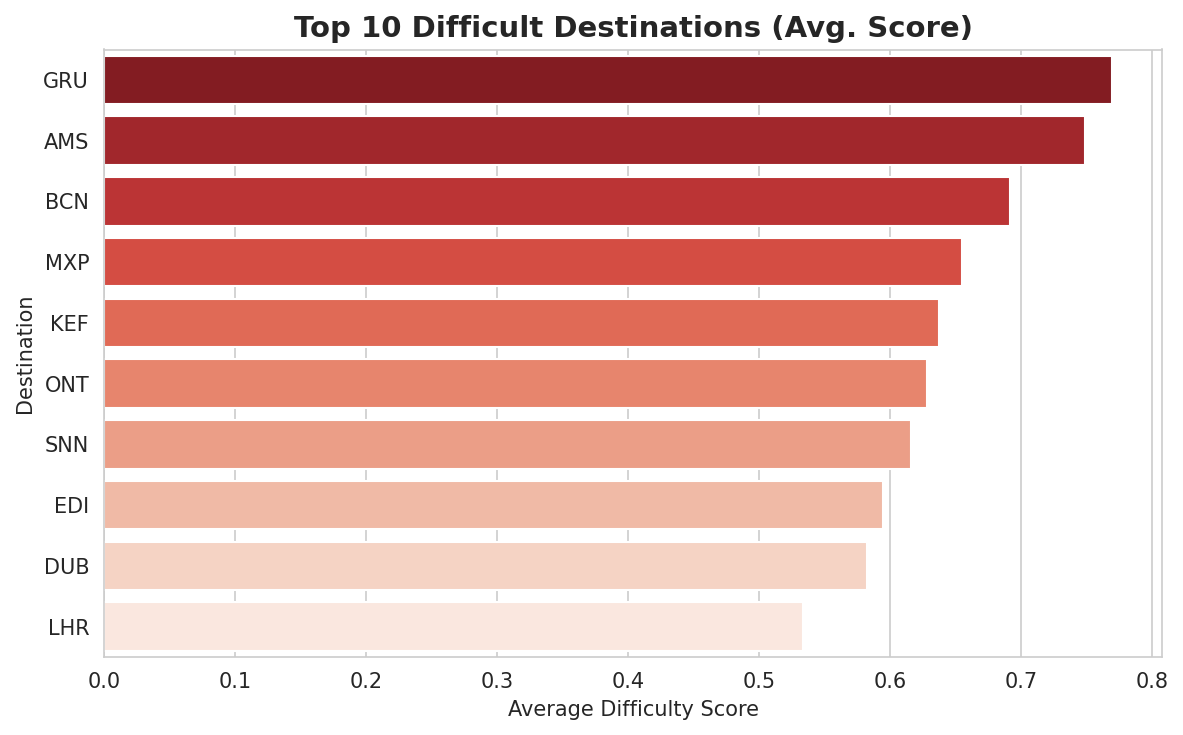

In [ ]:
# Average difficulty score by destination (from master table)
dest_difficulty = (
    df_master.groupby("scheduled_arrival_station_code")["difficulty_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5), dpi=150)
sns.barplot(x=dest_difficulty.values, y=dest_difficulty.index, palette="Reds_r")
plt.title("Top 10 Difficult Destinations (Avg. Score)", fontsize=14, weight="bold")
plt.xlabel("Average Difficulty Score")
plt.ylabel("Destination")
plt.tight_layout()
plt.show()


In [ ]:
# Flag domestic vs international
df_master["dom_int"] = df_master["arrival_country"].apply(lambda x: "Domestic" if x=="US" else "International")


/tmp/ipython-input-955264451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dom_int_scores.index, y=dom_int_scores.values,


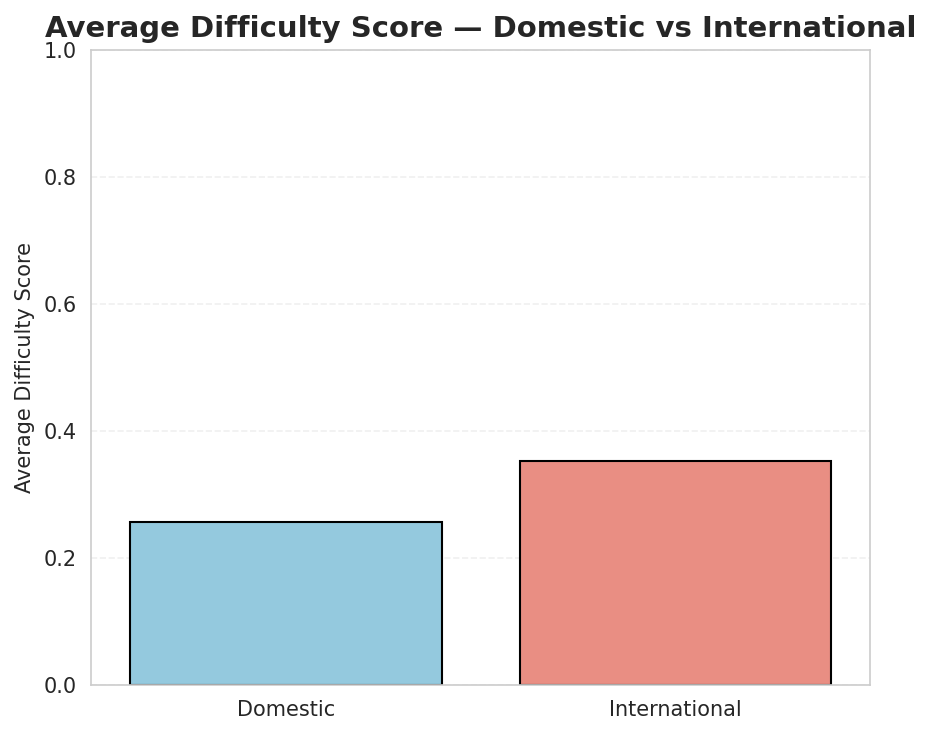

In [ ]:
# Average difficulty by Domestic vs International
dom_int_scores = df_master.groupby("dom_int")["difficulty_score"].mean()

plt.figure(figsize=(6,5), dpi=150)
sns.barplot(x=dom_int_scores.index, y=dom_int_scores.values,
            palette=["skyblue","salmon"], edgecolor="black")

plt.title("Average Difficulty Score — Domestic vs International", fontsize=14, weight="bold")
plt.ylabel("Average Difficulty Score")
plt.xlabel("")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


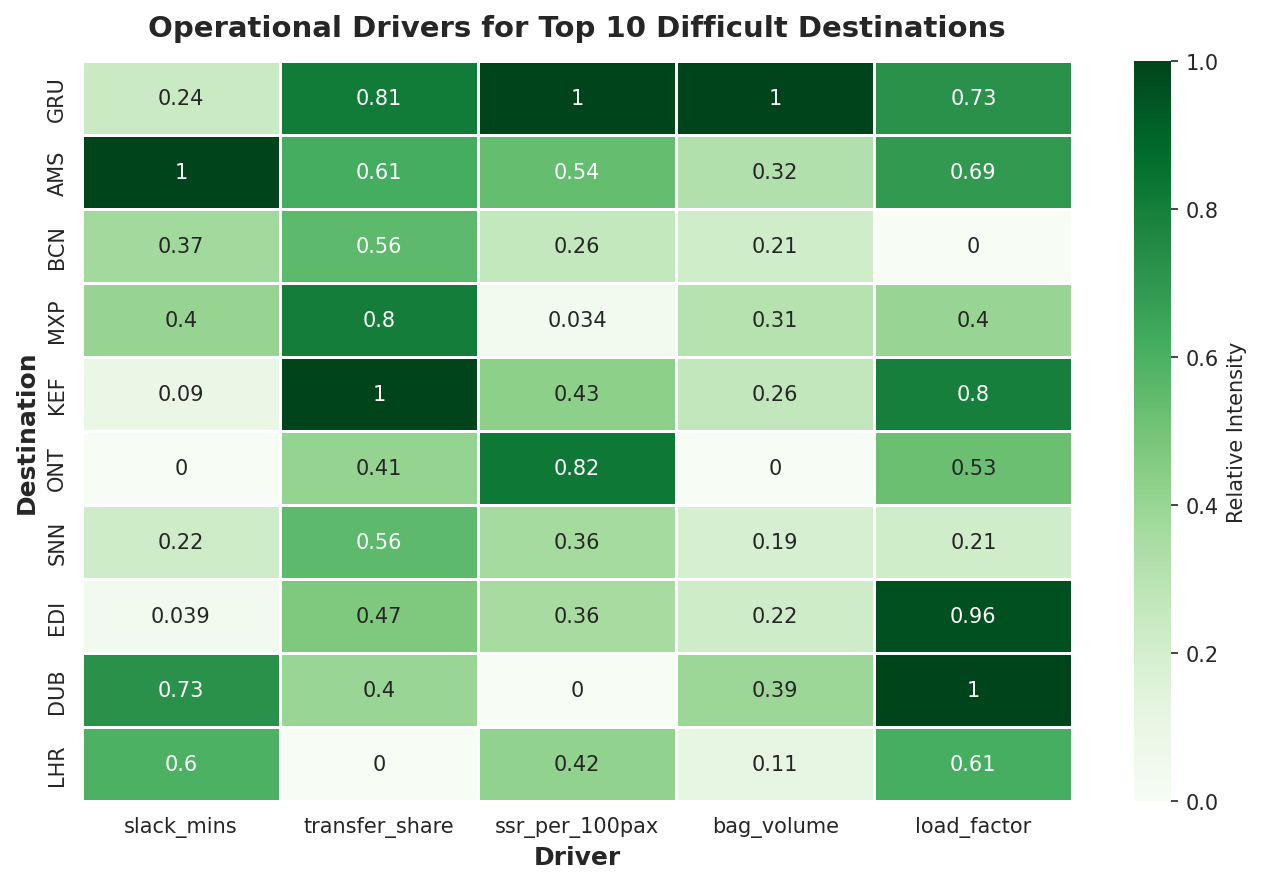

In [ ]:
# 1) Find top 10 difficult destinations
dest_difficulty = (
    df_master.groupby("scheduled_arrival_station_code")["difficulty_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_dests = dest_difficulty.index.tolist()

# 2) Aggregate driver metrics (fill missing with 0)
drivers = (
    df_master.groupby("scheduled_arrival_station_code")[
        ["slack_mins","transfer_share","ssr_per_100pax","bag_volume","load_factor"]
    ]
    .mean()
    .fillna(0)
)

# Keep only top destinations
drivers_top = drivers.loc[top_dests]

# 3) Normalize drivers for better comparison (0–1 scaling per column)
drivers_norm = (drivers_top - drivers_top.min()) / (drivers_top.max() - drivers_top.min())

# 4) Heatmap
plt.figure(figsize=(9,6), dpi=150)
sns.heatmap(drivers_norm, annot=True, cmap="Greens", cbar_kws={"label":"Relative Intensity"}, linewidths=0.5)

plt.title("Operational Drivers for Top 10 Difficult Destinations", fontsize=14, weight="bold", pad=12)
plt.xlabel("Driver", fontsize=12, weight="bold")
plt.ylabel("Destination", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


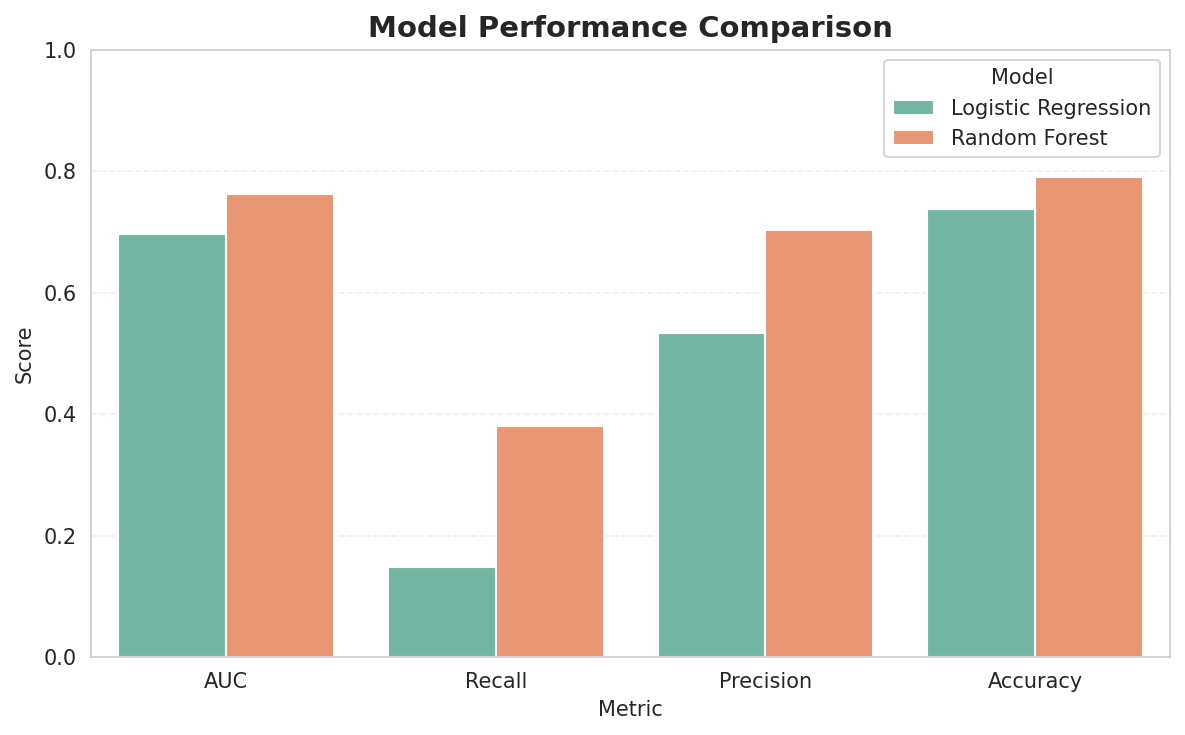

,Model,AUC,Recall,Precision,Accuracy
0,Logistic Regression,0.696676,0.148148,0.533333,0.737081
1,Random Forest,0.762077,0.379630,0.702857,0.790823


In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Train
    model.fit(X_train, y_train)
    # Predictions
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= 0.5).astype(int)
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    return {"Model": name, "AUC": auc, "Recall": recall, "Precision": precision, "Accuracy": acc}

# Evaluate Logistic Regression and Random Forest
results = []
results.append(evaluate_model("Logistic Regression", pipe, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Random Forest", pipe_rf, X_train, X_test, y_train, y_test))

import pandas as pd
results_df = pd.DataFrame(results)

# --- Bar Plot for Comparison ---
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5), dpi=150)
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Model Performance Comparison", fontsize=14, weight="bold")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

results_df


                 Model       AUC  Recall (Difficult)  Precision (Difficult)  \
0  Logistic Regression  0.696269            0.655864               0.393883   
1        Random Forest  0.762077            0.379630               0.702857   

   F1 (Difficult)  
0        0.492183  
1        0.492986  


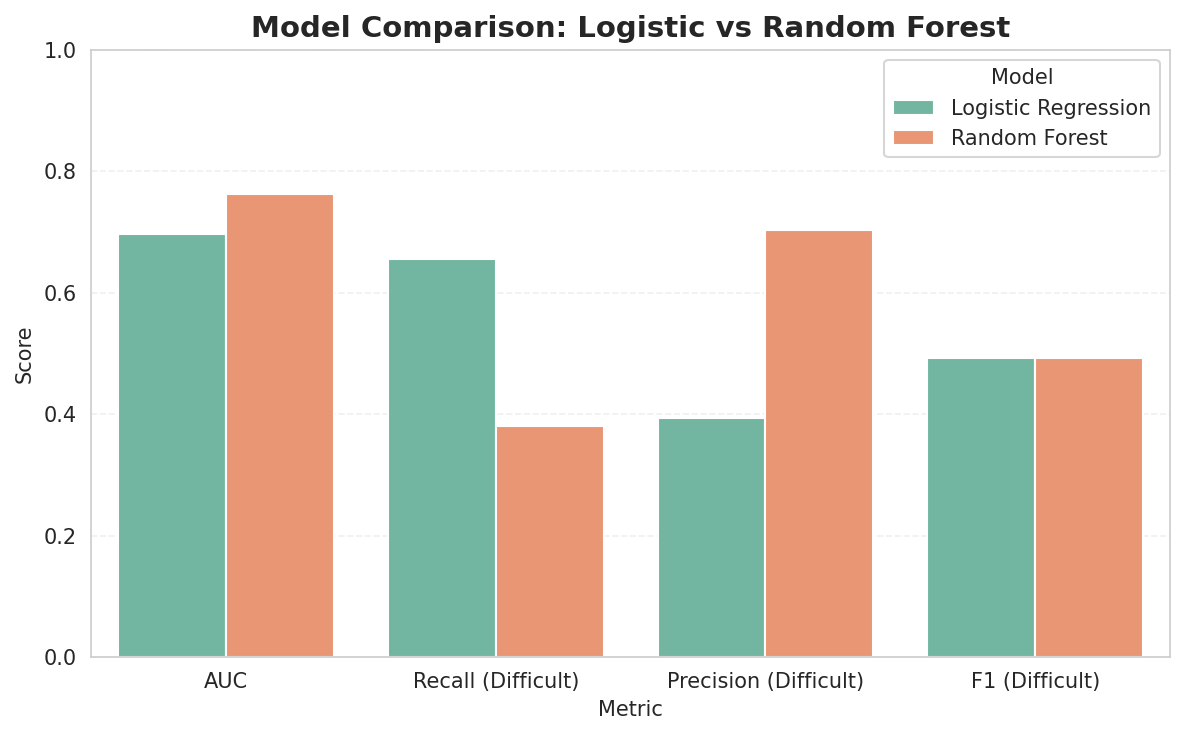

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier



# --- Logistic Regression ---
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
pipe_log = Pipeline([("pre", pre), ("clf", log_reg)])
pipe_log.fit(X_train, y_train)

log_proba = pipe_log.predict_proba(X_test)[:,1]
log_pred = (log_proba >= 0.5).astype(int)

log_results = {
    "Model": "Logistic Regression",
    "AUC": roc_auc_score(y_test, log_proba),
    "Recall (Difficult)": recall_score(y_test, log_pred),
    "Precision (Difficult)": precision_score(y_test, log_pred),
    "F1 (Difficult)": f1_score(y_test, log_pred)
}

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
pipe_rf = Pipeline([("pre", pre), ("clf", rf)])
pipe_rf.fit(X_train, y_train)

rf_proba = pipe_rf.predict_proba(X_test)[:,1]
rf_pred = (rf_proba >= 0.5).astype(int)

rf_results = {
    "Model": "Random Forest",
    "AUC": roc_auc_score(y_test, rf_proba),
    "Recall (Difficult)": recall_score(y_test, rf_pred),
    "Precision (Difficult)": precision_score(y_test, rf_pred),
    "F1 (Difficult)": f1_score(y_test, rf_pred)
}

# --- Combine results ---
import pandas as pd
comparison = pd.DataFrame([log_results, rf_results])
print(comparison)

# --- Plot side-by-side for slide ---
comparison_melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8,5), dpi=150)
sns.barplot(data=comparison_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Model Comparison: Logistic vs Random Forest", fontsize=14, weight="bold")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


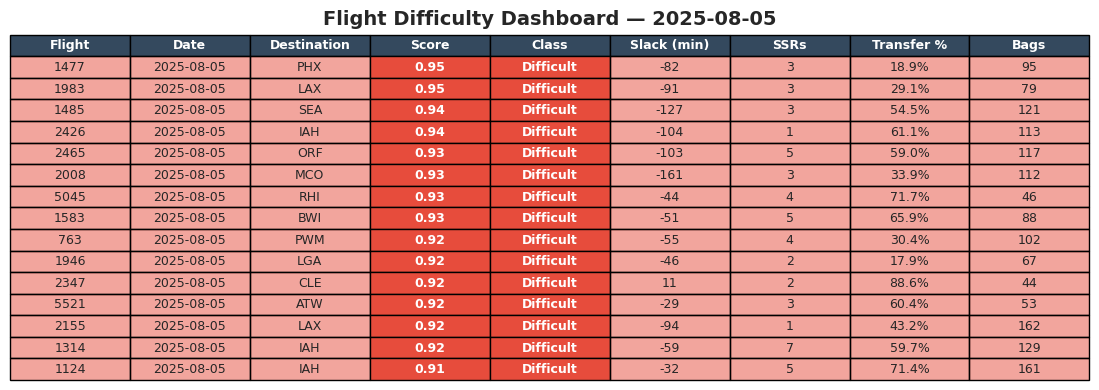

In [ ]:
# === 0) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# -------------------------------
# === 1) Ensure required features exist on df_master
# -------------------------------

# Load factor (cap at 1.0)
if "load_factor" not in df_master.columns:
    df_master["load_factor"] = (df_master["pax_total"] / df_master["total_seats"]).clip(upper=1.0)

# Slack minutes
if "slack_mins" not in df_master.columns:
    df_master["slack_mins"] = df_master["scheduled_ground_time_minutes"] - df_master["minimum_turn_minutes"]

# Bags: transfer_share, bag_volume
if "transfer_share" not in df_master.columns or "bag_volume" not in df_master.columns:
    checked = df_master["checked_bags"].fillna(0)
    transfer = df_master["transfer_bags"].fillna(0)
    total_bags = checked + transfer
    df_master["transfer_share"] = np.where(total_bags > 0, transfer / total_bags, 0.0)
    df_master["bag_volume"] = total_bags

# SSR per 100 pax
if "ssr_per_100pax" not in df_master.columns:
    pax = df_master["pax_total"].fillna(0)
    df_master["ssr_per_100pax"] = np.where(pax > 0, df_master["ssr_count"] / pax * 100, 0.0)

# dep_hour, dep_dow, cyclical encodings
if "dep_hour" not in df_master.columns:
    # Try to derive from timestamp if needed
    df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
    df_master["dep_hour"] = df_master["scheduled_departure_datetime_local"].dt.hour

if "dep_dow" not in df_master.columns:
    df_master["dep_dow"] = df_master["scheduled_departure_datetime_local"].dt.dayofweek  # 0=Mon

if "dep_hour_sin" not in df_master.columns or "dep_hour_cos" not in df_master.columns:
    df_master["dep_hour_sin"] = np.sin(2 * np.pi * df_master["dep_hour"] / 24)
    df_master["dep_hour_cos"] = np.cos(2 * np.pi * df_master["dep_hour"] / 24)

# Categorical hygiene
for col in ["fleet_type","carrier","arrival_country"]:
    if col in df_master.columns:
        df_master[col] = df_master[col].fillna("UNK").astype(str)

# -------------------------------
# === 2) Build/obtain difficulty_score
#    - Use existing pipe_rf & X if present, else train quickly here
# -------------------------------

feature_cols = [
    "slack_mins","load_factor","ssr_count","ssr_per_100pax",
    "transfer_share","bag_volume",
    "dep_hour_sin","dep_hour_cos","dep_dow",
    "checked_bags","transfer_bags",
    "fleet_type","carrier","arrival_country"
]

# Prepare X for prediction/training
missing_feats = [c for c in feature_cols if c not in df_master.columns]
if missing_feats:
    raise KeyError(f"Missing needed features on df_master: {missing_feats}")

X_all = df_master[feature_cols].copy()
cat_cols = ["fleet_type","carrier","arrival_country"]
num_cols = [c for c in feature_cols if c not in cat_cols]
X_all[num_cols] = X_all[num_cols].fillna(0)

# If pipe_rf exists, reuse it; else train a quick RF now
need_train = False
if "pipe_rf" not in globals():
    need_train = True
else:
    try:
        _ = pipe_rf.predict_proba(X_all.head(1))
    except Exception:
        need_train = True

if need_train:
    pre_local = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop"
    )
    rf_local = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    pipe_rf = Pipeline([("pre", pre_local), ("clf", rf_local)])
    # Train using the whole dataset (quick pragmatic fit for mockup)
    # If you still have y/ splits, you can replace this with your trained pipe
    if "is_difficult" not in df_master.columns:
        # Build target from dep_delay_min if needed
        if "dep_delay_min" not in df_master.columns:
            df_master["actual_departure_datetime_local"] = pd.to_datetime(df_master["actual_departure_datetime_local"])
            df_master["dep_delay_min"] = (
                (df_master["actual_departure_datetime_local"] - df_master["scheduled_departure_datetime_local"])
                .dt.total_seconds() / 60
            )
        df_master["is_difficult"] = (df_master["dep_delay_min"] > 15).astype(int)
    y_all = df_master["is_difficult"].astype(int)
    pipe_rf.fit(X_all, y_all)

# Compute difficulty_score if missing
if "difficulty_score" not in df_master.columns:
    df_master["difficulty_score"] = pipe_rf.predict_proba(X_all)[:, 1]

# -------------------------------
# === 3) Recompute daily ranks + classes (safe)
# -------------------------------
df_master["daily_rank"] = (
    df_master.groupby("scheduled_departure_date_local")["difficulty_score"]
    .rank(method="first", ascending=False)
)

df_master["rank_pct"] = (
    (df_master["daily_rank"] - 1) /
    (df_master.groupby("scheduled_departure_date_local")["difficulty_score"].transform("size") - 1)
)

df_master["difficulty_class"] = pd.cut(
    df_master["rank_pct"].clip(0,1),
    bins=[0,0.2,0.5,1.0],
    labels=["Difficult","Medium","Easy"],
    include_lowest=True
)

# -------------------------------
# === 4) Dashboard mockup (sample day)
# -------------------------------
# Pick a day that exists; if 2025-08-05 not present, auto-pick the first day
sample_date = "2025-08-05"
if sample_date not in set(df_master["scheduled_departure_date_local"].astype(str)):
    sample_date = str(df_master["scheduled_departure_date_local"].iloc[0])

sample_day = (
    df_master[df_master["scheduled_departure_date_local"].astype(str) == sample_date]
    .sort_values("daily_rank")
    .head(15)
    .copy()
)

dash = sample_day[[
    "flight_number","scheduled_departure_date_local",
    "scheduled_arrival_station_code","difficulty_score",
    "difficulty_class","slack_mins","ssr_count","transfer_share","bag_volume"
]].copy()

# Format for readability
dash["difficulty_score"] = dash["difficulty_score"].round(2)
dash["transfer_share"] = (dash["transfer_share"]*100).round(1).astype(str) + "%"
dash["bag_volume"] = dash["bag_volume"].fillna(0).astype(int)

# --- Pretty table with row tint by class
color_map = {"Difficult":"#e74c3c", "Medium":"#f39c12", "Easy":"#27ae60"}

fig, ax = plt.subplots(figsize=(11,4))
ax.axis("off")

table = ax.table(
    cellText=dash.values,
    colLabels=["Flight","Date","Destination","Score","Class","Slack (min)","SSRs","Transfer %","Bags"],
    cellLoc="center",
    loc="center"
)

# Header style
for (r,c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#34495e")
        cell.set_text_props(color="white", weight="bold")

# Tint entire row by class (light alpha), keep text readable
for r in range(1, len(dash)+1):
    cls = dash.iloc[r-1]["difficulty_class"]
    tint = color_map.get(cls, "#bdc3c7")
    for c in range(len(dash.columns)):
        cell = table[r, c]
        if c != 3 and c != 4:  # keep score/class more contrasted by not over-tinting
            cell.set_facecolor(tint + "80" if len(tint)==7 else tint)  # add alpha if hex
        else:
            cell.set_facecolor(color_map[cls])
            cell.set_text_props(color="white", weight="bold")

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.2)

plt.title(f"Flight Difficulty Dashboard — {sample_date}", fontsize=14, weight="bold", pad=12)
plt.tight_layout()
plt.show()


What if analysis

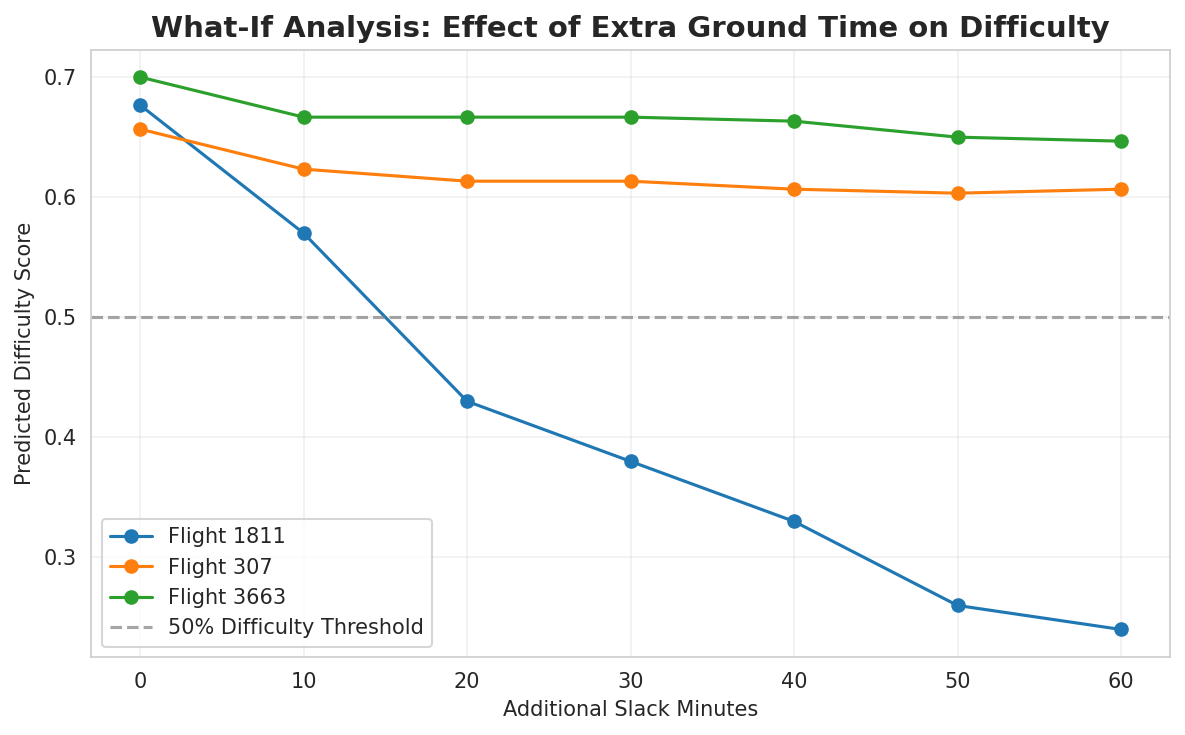

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Pick a few sample "difficult" flights ---
difficult_flights = df_master[df_master["difficulty_class"]=="Difficult"].head(3).copy()

# --- 2) Scenarios: add +0 to +60 mins slack ---
scenarios = np.arange(0, 61, 10)  # 0,10,...60

results = []
for idx, row in difficult_flights.iterrows():
    for extra in scenarios:
        modified = row.copy()
        modified["slack_mins"] = row["slack_mins"] + extra
        # Need a DataFrame for prediction
        X_sim = pd.DataFrame([modified[feature_cols]])
        score = pipe_rf.predict_proba(X_sim)[:,1][0]
        results.append({
            "flight_number": row["flight_number"],
            "extra_slack": extra,
            "difficulty_score": score
        })

sim_df = pd.DataFrame(results)

# --- 3) Plot curves ---
plt.figure(figsize=(8,5), dpi=150)
for flight in sim_df["flight_number"].unique():
    subset = sim_df[sim_df["flight_number"]==flight]
    plt.plot(subset["extra_slack"], subset["difficulty_score"], marker="o", label=f"Flight {flight}")

plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="50% Difficulty Threshold")
plt.title("What-If Analysis: Effect of Extra Ground Time on Difficulty", fontsize=14, weight="bold")
plt.xlabel("Additional Slack Minutes")
plt.ylabel("Predicted Difficulty Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# --- Aggregate insights across all difficult flights ---
summary = (
    sim_df.groupby("extra_slack")["difficulty_score"]
    .mean()
    .reset_index()
    .rename(columns={"difficulty_score":"avg_score"})
)

# Compute % reduction relative to baseline (0 slack)
baseline = summary.loc[summary["extra_slack"]==0, "avg_score"].values[0]
summary["reduction_vs_baseline"] = (baseline - summary["avg_score"]) / baseline * 100

print("Business Insight: Average effect of adding slack minutes")
print(summary)


In [ ]:
# --- Pick a few sample difficult flights again ---
difficult_flights_ssr = df_master[df_master["difficulty_class"]=="Difficult"].head(3).copy()

# --- Simulate reducing SSR count by 0, 5, 10, 15 ---
ssr_reductions = [0, 5, 10, 15]

results_ssr = []
for idx, row in difficult_flights_ssr.iterrows():
    for reduction in ssr_reductions:
        modified = row.copy()
        modified["ssr_count"] = max(0, row["ssr_count"] - reduction)
        X_sim = pd.DataFrame([modified[feature_cols]])
        score = pipe_rf.predict_proba(X_sim)[:,1][0]
        results_ssr.append({
            "flight_number": row["flight_number"],
            "ssr_reduction": reduction,
            "difficulty_score": score
        })

sim_ssr_df = pd.DataFrame(results_ssr)

# --- Aggregate average impact across flights ---
summary_ssr = (
    sim_ssr_df.groupby("ssr_reduction")["difficulty_score"]
    .mean()
    .reset_index()
    .rename(columns={"difficulty_score":"avg_score"})
)

baseline_ssr = summary_ssr.loc[summary_ssr["ssr_reduction"]==0, "avg_score"].values[0]
summary_ssr["reduction_vs_baseline"] = (baseline_ssr - summary_ssr["avg_score"]) / baseline_ssr * 100

print("Business Insight: Average effect of reducing SSR count")
print(summary_ssr)

# --- Plot ---
plt.figure(figsize=(8,5), dpi=150)
plt.plot(summary_ssr["ssr_reduction"], summary_ssr["avg_score"], marker="o", color="navy")
plt.title("What-If Analysis: Effect of Reducing SSR Requests", fontsize=14, weight="bold")
plt.xlabel("SSR Reduction (number of requests)")
plt.ylabel("Predicted Difficulty Score (avg)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Flight difficulty heatmap

In [ ]:
# ===========================
# Flight Risk Heatmap Dashboard (Control-room style)
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# -------- Config --------
sample_date = None   # e.g., "2025-08-05"; leave None to auto-pick busiest day
top_k_dest = 20      # show top N destinations by flight count for the day
show_outline = True  # cell borders for a control-room look

# -------- 0) Sanity: required columns / features --------
# dep_hour
if "dep_hour" not in df_master.columns:
    df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
    df_master["dep_hour"] = df_master["scheduled_departure_datetime_local"].dt.hour

# load_factor
if "load_factor" not in df_master.columns:
    df_master["load_factor"] = (df_master["pax_total"] / df_master["total_seats"]).clip(upper=1.0)

# slack_mins
if "slack_mins" not in df_master.columns:
    df_master["slack_mins"] = df_master["scheduled_ground_time_minutes"] - df_master["minimum_turn_minutes"]

# transfer_share & bag_volume
if ("transfer_share" not in df_master.columns) or ("bag_volume" not in df_master.columns):
    checked = df_master["checked_bags"].fillna(0)
    transfer = df_master["transfer_bags"].fillna(0)
    total_bags = checked + transfer
    df_master["transfer_share"] = np.where(total_bags > 0, transfer / total_bags, 0.0)
    df_master["bag_volume"] = total_bags

# ssr_per_100pax
if "ssr_per_100pax" not in df_master.columns:
    pax = df_master["pax_total"].fillna(0)
    df_master["ssr_per_100pax"] = np.where(pax > 0, df_master["ssr_count"] / pax * 100, 0.0)

# cyclical hour
if "dep_hour_sin" not in df_master.columns or "dep_hour_cos" not in df_master.columns:
    df_master["dep_hour_sin"] = np.sin(2 * np.pi * df_master["dep_hour"] / 24)
    df_master["dep_hour_cos"] = np.cos(2 * np.pi * df_master["dep_hour"] / 24)

# dep_dow
if "dep_dow" not in df_master.columns:
    df_master["dep_dow"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"]).dt.dayofweek

# categorical hygiene
for c in ["fleet_type","carrier","arrival_country"]:
    if c in df_master.columns:
        df_master[c] = df_master[c].fillna("UNK").astype(str)

# -------- 1) Difficulty score (reuse pipe_rf if available; else train quick) --------
feature_cols = [
    "slack_mins","load_factor","ssr_count","ssr_per_100pax",
    "transfer_share","bag_volume","dep_hour_sin","dep_hour_cos","dep_dow",
    "checked_bags","transfer_bags","fleet_type","carrier","arrival_country"
]
cat_cols = ["fleet_type","carrier","arrival_country"]
num_cols = [c for c in feature_cols if c not in cat_cols]

missing_feats = [c for c in feature_cols if c not in df_master.columns]
if missing_feats:
    raise KeyError(f"Missing features on df_master: {missing_feats}")

X_all = df_master[feature_cols].copy()
X_all[num_cols] = X_all[num_cols].fillna(0)

need_train = False
if "pipe_rf" not in globals():
    need_train = True
else:
    try:
        _ = pipe_rf.predict_proba(X_all.head(1))
    except Exception:
        need_train = True

if need_train:
    pre_local = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop"
    )
    rf_local = RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight="balanced",
        random_state=42, n_jobs=-1
    )
    pipe_rf = Pipeline([("pre", pre_local), ("clf", rf_local)])
    # Build quick target if needed
    if "is_difficult" not in df_master.columns:
        if "dep_delay_min" not in df_master.columns:
            df_master["scheduled_departure_datetime_local"] = pd.to_datetime(df_master["scheduled_departure_datetime_local"])
            df_master["actual_departure_datetime_local"] = pd.to_datetime(df_master["actual_departure_datetime_local"])
            df_master["dep_delay_min"] = (
                (df_master["actual_departure_datetime_local"] - df_master["scheduled_departure_datetime_local"])
                .dt.total_seconds() / 60
            )
        df_master["is_difficult"] = (df_master["dep_delay_min"] > 15).astype(int)
    y_all = df_master["is_difficult"].astype(int)
    pipe_rf.fit(X_all, y_all)

if "difficulty_score" not in df_master.columns:
    df_master["difficulty_score"] = pipe_rf.predict_proba(X_all)[:, 1]

# -------- 2) Pick date & subset --------
dates = df_master["scheduled_departure_date_local"].astype(str)
if sample_date is None or sample_date not in set(dates):
    sample_date = dates.value_counts().idxmax()  # busiest day

df_day = df_master[dates == sample_date].copy()
if df_day.empty:
    raise ValueError("No flights found for the selected day.")

# -------- 3) Choose top destinations by flight count (for readability) --------
top_dests = (
    df_day.groupby("scheduled_arrival_station_code")
    .size()
    .sort_values(ascending=False)
    .head(top_k_dest)
    .index
)

df_day = df_day[df_day["scheduled_arrival_station_code"].isin(top_dests)].copy()

# Ensure hour columns 0..23 exist
all_hours = list(range(24))

# Pivot: mean difficulty by destination × hour
pivot_mean = (
    df_day.pivot_table(
        index="scheduled_arrival_station_code",
        columns="dep_hour",
        values="difficulty_score",
        aggfunc="mean"
    )
    .reindex(columns=all_hours)
    .sort_index()
)

# Optional: order destinations by overall mean difficulty (highest at top)
row_order = pivot_mean.mean(axis=1).sort_values(ascending=False).index
pivot_mean = pivot_mean.reindex(index=row_order)

# -------- 4) Plot heatmap --------
plt.figure(figsize=(12, max(6, 0.35*len(pivot_mean))), dpi=150)
ax = sns.heatmap(
    pivot_mean,
    cmap="YlOrRd",
    vmin=0, vmax=1,  # scores are probabilities
    linewidths=0.4 if show_outline else 0,
    linecolor="white" if show_outline else None,
    cbar_kws={"label": "Avg Difficulty Score"}
)

ax.set_title(f"Daily Flight Risk Heatmap — {sample_date}\nDestination × Departure Hour (Avg Difficulty Score)",
             fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Departure Hour (Local)", fontsize=11, fontweight="bold")
ax.set_ylabel("Destination", fontsize=11, fontweight="bold")
ax.set_xticks(np.arange(0.5, 24.5, 1))
ax.set_xticklabels(all_hours, rotation=0)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()


Economical analysis

In [ ]:
# ============================
# ECONOMIC IMPACT — Baseline & Savings Scenarios (Single Block)
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style ---
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# --- Assumptions ---
COST_PER_MIN_OPTIONS = [50, 75, 100]     # $ cost per delay minute (sensitivity)
REDUCTION_MINUTES = [3, 5, 10]           # target reduction per Difficult flight (minutes)
SHOW_COST_PER_MIN_FOR_DAILY = 75         # cost assumption for daily baseline chart

# --- Load data ---
df = df_master.copy()

# --- Ensure needed columns ---
if "dep_delay_min" not in df.columns:
    df["scheduled_departure_datetime_local"] = pd.to_datetime(df["scheduled_departure_datetime_local"])
    df["actual_departure_datetime_local"] = pd.to_datetime(df["actual_departure_datetime_local"])
    df["dep_delay_min"] = (
        (df["actual_departure_datetime_local"] - df["scheduled_departure_datetime_local"])
        .dt.total_seconds() / 60
    )

df["dep_delay_pos"] = df["dep_delay_min"].clip(lower=0)

if "difficulty_class" not in df.columns:
    if "difficulty_score" not in df.columns:
        raise KeyError("difficulty_score or difficulty_class not found. Run the scoring step first.")
    df["daily_rank"] = (
        df.groupby("scheduled_departure_date_local")["difficulty_score"]
          .rank(method="first", ascending=False)
    )
    df["rank_pct"] = (
        (df["daily_rank"] - 1) /
        (df.groupby("scheduled_departure_date_local")["difficulty_score"].transform("size") - 1)
    )
    df["difficulty_class"] = pd.cut(
        df["rank_pct"].clip(0,1),
        bins=[0,0.2,0.5,1.0],
        labels=["Difficult","Medium","Easy"],
        include_lowest=True
    )

# --- Baseline: avg delay per class ---
class_delay = (
    df.groupby("difficulty_class")["dep_delay_pos"]
      .mean()
      .reindex(["Easy","Medium","Difficult"])
)

# --- Savings scenarios ---
difficult = df[df["difficulty_class"] == "Difficult"].copy()
savings_matrix = []
for red in REDUCTION_MINUTES:
    mins_saved = np.minimum(difficult["dep_delay_pos"].values, red).sum()
    row = {"Reduction (min)": red, "Total minutes saved": mins_saved}
    for cpm in COST_PER_MIN_OPTIONS:
        row[f"${cpm}/min"] = mins_saved * cpm
    savings_matrix.append(row)
savings_df = pd.DataFrame(savings_matrix)
heatmap_df = savings_df.set_index("Reduction (min)")[[f"${c}/min" for c in COST_PER_MIN_OPTIONS]]

# --- Daily total cost ---
daily_cost = (
    df.groupby("scheduled_departure_date_local")["dep_delay_pos"]
      .sum()
      .sort_index()
      * SHOW_COST_PER_MIN_FOR_DAILY
)
daily_cost = daily_cost.rename(f"Total Cost @ ${SHOW_COST_PER_MIN_FOR_DAILY}/min")

# ============================
# PLOTS
# ============================

colors = {"Easy":"#2ecc71","Medium":"#f39c12","Difficult":"#e74c3c"}

# (A) Average delay by class
fig, ax = plt.subplots(figsize=(8,5), dpi=150)
bars = ax.bar(class_delay.index, class_delay.values,
              color=[colors[cat] for cat in class_delay.index],
              edgecolor='white', linewidth=2, alpha=0.9)
for bar, v in zip(bars, class_delay.values):
    ax.text(bar.get_x()+bar.get_width()/2., v+0.8, f"{v:.1f} min",
            ha='center', va='bottom', fontsize=11, weight='bold', color="#2c3e50")
ax.set_title("Average Departure Delay by Difficulty Class", fontsize=15, weight='bold', pad=15)
ax.set_ylabel("Average Delay (minutes)", fontsize=12, weight='bold')
ax.set_ylim(0, max(class_delay.values)*1.3)
plt.tight_layout()
plt.show()

# (B) Savings heatmap
fig, ax = plt.subplots(figsize=(8,5.5), dpi=150)
sns.heatmap(heatmap_df/1000, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=2, linecolor='white',
            cbar_kws={'label': 'Estimated Savings ($1000s)', 'shrink': 0.8},
            square=True, annot_kws={'size':11, 'weight':'bold'}, ax=ax)
ax.set_title("Potential Cost Savings: Reducing Delays on Difficult Flights",
             fontsize=15, weight='bold', pad=15)
ax.set_xlabel("Cost per Delay Minute", fontsize=12, weight='bold')
ax.set_ylabel("Avg Reduction per Difficult Flight (minutes)", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

# (C) Daily cost trend
fig, ax = plt.subplots(figsize=(10,5), dpi=150)
daily_cost.plot(kind="bar", color="#34495e", edgecolor="white", linewidth=1.2, ax=ax)
for i, v in enumerate(daily_cost.values):
    ax.text(i, v+max(daily_cost.values)*0.01, f"${v/1000:.1f}K",
            ha='center', va='bottom', fontsize=10, weight='bold', color="#2c3e50")
ax.set_title(f"Daily Cost of Departure Delays @ ${SHOW_COST_PER_MIN_FOR_DAILY}/min",
             fontsize=15, weight='bold', pad=15)
ax.set_ylabel("Total Cost ($)", fontsize=12, weight='bold')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ============================
# PRINT NUMBERS (for PPT text)
# ============================
print("\nBaseline context (avg positive delay by class, minutes):")
print(class_delay.round(2))

print("\nSavings scenarios (Difficult flights only):")
print(savings_df.round(0))

print("\nDaily total cost @ chosen rate:")
print(daily_cost.round(0))


In [ ]:
print(class_delay.round(2))


In [ ]:
print(savings_df.round(0))


In [ ]:
print(daily_cost.round(0))
